# Temuco heating study
*Are there Synergies and Tradeoffs in Sustainable Heating from More Efficient Stoves and Home Insulation?* — manuscript **EARE-D-25-01712 (R2)**

**Reading guide.** Parts&nbsp;0–4 reproduce the paper's analysis as submitted. **Part&nbsp;5** is the new spatial-identification response to Reviewer #1 (neighborhood fixed effects, the granularity ladder, and Conley standard errors). **Part&nbsp;6** writes every table into a single workbook. Blockquote callouts marked *“Responds to …”* flag where each reviewer comment is answered; the full comment→section map is in the next cell.

**Contents**

- **Part 0** · Model, setup and data
- **Part 1** · Treatment assignment — GPS weighting & balance  *(R1 C2, C4)*
- **Part 2** · Indoor PM₂.₅ and temperature  *(R1 C5, C6a/c; R2)*
- **Part 3** · Fuel cost  *(R1 C6b, C6c)*
- **Part 4** · Reporting — exports, summary, primary-results figure
- **Part 5** · Spatial identification: neighborhood FE, granularity ladder, Conley  *(Editor i–ii; R1 C6a)*  — **new**
- **Part 6** · Consolidated results workbook

## Where each comment is answered

| Editor / Reviewer comment | Answered in |
|---|---|
| **Editor (i)** — report the specification proposed by the reviewer | *Reviewer response* → spatial-FE derivation + **Reviewer Eq (1′)** |
| **Editor (ii)** — run that specification with waking hours as heterogeneity | *Reviewer response* → **Waking-hours heterogeneity** |
| **Editor (iii)** — spell out what matching can/cannot deliver (unconfoundedness) | *Identification assumptions and interpretation* |
| **Editor (iv)** — move material to an appendix / streamline | Manuscript organization (not code) |
| **R1 C2** — are the prioritization criteria in the propensity score? | *Setup* → Multinomial GPS weights |
| **R1 C4** — all pre-determined variables in the PS; balance | *Setup* → GPS weights + Covariate-balance diagnostics |
| **R1 C5** — exclude the 25 non-MINVU (post-2015) insulated dwellings | Part I → *Sensitivity: exclude 25* |
| **“higher-level” spatial FE / more neighborhoods** | *Robustness to spatial resolution* → granularity ladder (2→4→8→12→20 units) |
| **R1 C6a** — drop W as identifying; neighborhood + hour FE, main effects | *Reviewer response* → **Reviewer Eq (1′)** (+ heterogeneity) |
| **R1 C6b** — fuel cost: exclude HoursUsed; HC1 standard errors | Part II → Fuel-cost models |
| **R1 C6c** — document how standard errors are computed | Table notes (clustered by ID for panel; HC1 for cost) |
| **R2 C1–C5** — waking-hours interpretation, rebound, all-hours averaging | Part I waking tables + *Reviewer response* (all-hours main spec) |

---

# Part 0 · Model, setup and data

## Model, notation, and analysis overview
## Analysis overview and model definitions  ·  v3 (response to reviewers)

This notebook provides a complete and reproducible analysis of three household outcomes:

1. indoor PM₂.₅ concentrations;
2. indoor temperature;
3. fuel expenditure over the 48-hour monitoring period.

The analysis compares four mutually exclusive heating–insulation groups:

- firewood without insulation;
- pellet only;
- insulation only;
- pellet plus insulation.

Firewood without insulation is the reference group throughout the analysis. Stabilized multinomial generalized propensity-score (GPS) weights are used to improve comparability across groups on observed pretreatment household and dwelling characteristics.

---

## Generalized propensity-score weighting

Let $G_i \in \{0,1,2,3\}$ denote the observed heating–insulation group of household $i$, and let $X_i$ denote the vector of observed pretreatment covariates.

The multinomial generalized propensity score is:

$$
\widehat{p}_{ig}
=
\widehat{\Pr}\left(G_i=g \mid X_i\right).
$$

The stabilized inverse-probability weight assigned to household $i$ is:

$$
SW_i
=
\frac{\Pr(G_i=g)}
{\widehat{\Pr}\left(G_i=g \mid X_i\right)},
\qquad g=G_i.
$$

Weights are trimmed at the 1st and 99th percentiles to limit the influence of extreme observations. Weight distributions, effective sample size, treatment-group overlap, and covariate balance are reported as diagnostics.

---

# Part I. Indoor PM₂.₅ and temperature

## Main all-hours specification

Indoor PM₂.₅ and temperature are observed repeatedly at the household-hour level. For outcome $Y_{it}$, the main specification is:

$$
\begin{aligned}
\ln(Y_{it}) =\;&
\alpha
+\beta_1 Pellet_i
+\beta_2 Insulation_i
+\beta_3\left(Pellet_i \times Insulation_i\right) \\
&+\lambda_1 \ln(PM^{out}_{it})
+\lambda_2 \ln(T^{out}_{it}) \\
&+\delta_h+\gamma_d+\mu_m+\varepsilon_{it}.
\end{aligned}
$$

where:

- $i$ denotes the household;
- $t$ denotes the hourly observation;
- $PM^{out}_{it}$ is outdoor PM₂.₅;
- $T^{out}_{it}$ is outdoor temperature;
- $\delta_h$ represents hour-of-day fixed effects;
- $\gamma_d$ represents measurement-day fixed effects;
- $\mu_m$ represents municipality fixed effects;
- standard errors are clustered at the household level.

Household fixed effects are not included because pellet-stove and insulation status do not vary within households during the monitoring period.

The treatment-group contrasts relative to firewood without insulation are:

$$
\Delta_{\text{Pellet}}
=
\beta_1,
$$

$$
\Delta_{\text{Insulation}}
=
\beta_2,
$$

and

$$
\Delta_{\text{Pellet+Insulation}}
=
\beta_1+\beta_2+\beta_3.
$$

Because the dependent variables are expressed in logarithms, estimated contrasts are converted into exact percentage differences using:

$$
\%\Delta
=
100\left[\exp(\Delta)-1\right].
$$

The interaction coefficient $\beta_3$ measures departure from additivity on the log-outcome scale. The notebook also reports direct comparisons between the combined group and each single-intervention group.

---

## Waking-hours heterogeneity

Let $W_t=1$ for observations recorded during the predefined waking-hours period and $W_t=0$ otherwise.

The preferred heterogeneity specification is:

$$
\begin{aligned}
\ln(Y_{it}) =\;&
\alpha
+\beta_1 Pellet_i
+\beta_2 Insulation_i
+\beta_3\left(Pellet_i \times Insulation_i\right) \\
&+\theta_1\left(W_t \times Pellet_i\right)
+\theta_2\left(W_t \times Insulation_i\right) \\
&+\theta_3\left(W_t \times Pellet_i \times Insulation_i\right) \\
&+\lambda_1 \ln(PM^{out}_{it})
+\lambda_2 \ln(T^{out}_{it}) \\
&+\delta_h+\gamma_d+\mu_m+\varepsilon_{it}.
\end{aligned}
$$

The main effect of $W_t$ is omitted because waking hours are determined by the hour of the day and are therefore collinear with the complete set of hour fixed effects.

The coefficients $\theta_1$, $\theta_2$, and $\theta_3$ indicate whether treatment-group differences during waking hours differ from those observed during non-waking hours.

For example, the total waking-hours difference for the combined group is:

$$
\Delta^{W}_{\text{Pellet+Insulation}}
=
\beta_1+\beta_2+\beta_3
+\theta_1+\theta_2+\theta_3.
$$

---

## Temperature interpretation

Indoor temperature is transformed using Kelvin:

$$
T^{K}_{it}
=
T^{C}_{it}+273.15,
$$

and the dependent variable is:

$$
\ln(T^{K}_{it}).
$$

Therefore, percentage changes refer to absolute temperature measured in Kelvin. For interpretation in degrees Celsius, a log-scale contrast $\Delta$ is translated at a reference temperature $T^{C}_{ref}$ as:

$$
\Delta\,^{\circ}\mathrm{C}
=
\left(T^{C}_{ref}+273.15\right)
\left[\exp(\Delta)-1\right].
$$

The notebook uses the observed mean temperature of the firewood-without-insulation group as the reference value.

---

# Part II. Fuel-cost analysis

Fuel expenditure is observed once per household for the 48-hour monitoring period. The main cross-sectional cost equation is:

$$
Cost_i
=
\theta_0
+\theta_1 Pellet_i
+\theta_2 Insulation_i
+\theta_3\left(Pellet_i \times Insulation_i\right)
+u_i.
$$

Here, $Cost_i$ represents household fuel expenditure over the 48-hour monitoring period, measured in Chilean pesos.

The treatment-group cost differences relative to firewood without insulation are:

$$
\Delta Cost_{\text{Pellet}}
=
\theta_1,
$$

$$
\Delta Cost_{\text{Insulation}}
=
\theta_2,
$$

and

$$
\Delta Cost_{\text{Pellet+Insulation}}
=
\theta_1+\theta_2+\theta_3.
$$

The main cost specification uses stabilized multinomial GPS weights and heteroskedasticity-robust HC1 standard errors. Additional specifications assess sensitivity to municipality fixed effects, direct covariate adjustment, and alternative GPS weights.

Stove-use duration is not included as a control because it may be affected by treatment and may therefore lie on the pathway between heating technology and fuel expenditure.

---

## Structure of the notebook

- **Part I:** hourly indoor PM₂.₅ and temperature outcomes;
- **Part II:** cross-sectional fuel-cost outcome;
- **Diagnostics:** weight distributions, effective sample size, overlap, and covariate balance;
- **Heterogeneity:** waking versus non-waking periods;
- **Complementarity:** interaction coefficients and pairwise treatment-group comparisons;
- **Sensitivity analyses:** alternative adjustment strategies, waking-hour definitions, and exclusion of a specific insulated subgroup;
- **Outputs:** publication-ready tables, complete model summaries, and a three-panel figure.

The estimates are most conservatively interpreted as GPS-adjusted differences between observed treatment groups. A causal interpretation additionally requires conditional unconfoundedness, positivity and common support, consistency, no interference, accurate measurement, and adequate specification of the propensity-score and outcome models.

In [1]:
# ============================================================
# 1. IMPORTS AND SETTINGS
# ============================================================
# This cell loads the required packages, defines analysis constants,
# locates the input workbook, and creates a portable output directory.

from pathlib import Path
from itertools import combinations
import warnings

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from scipy import stats as st
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

SEED = 42
TRIM_PCT = (1, 99)
WAKE_START = 7
WAKE_END = 22  # inclusive: 07:00–22:59
MUNICIPALITY_FE = "Comuna"
CLP_PER_USD = 740.0
VERSION_LABEL = "v3 — 28 July 2026"

# Portable input search: first beside the notebook, then in common project locations.
FILE_CANDIDATES = [
    Path("Panel_03112025.xlsx"),
    Path.home() / "Documents" / "Fito" / "Temuco_2025" / "Panel_03112025.xlsx",
    Path.home() / "Documents" / "Fito" / "Temuco_2025" / "Current-review" / "Panel_03112025.xlsx",
    Path("/mnt/data/Panel_03112025.xlsx"),
]
FILE_PATH = next((path for path in FILE_CANDIDATES if path.exists()), None)
if FILE_PATH is None:
    raise FileNotFoundError(
        "Panel_03112025.xlsx was not found. Place it beside this notebook or update FILE_CANDIDATES."
    )

OUT_DIR = FILE_PATH.resolve().parent / "Output_v3"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_XLSX = OUT_DIR / "Temuco_Heating_Analysis_v3.xlsx"
OUTPUT_TXT = OUT_DIR / "Temuco_Heating_Model_Summaries_v3.txt"
OUTPUT_PLOT = OUT_DIR / "Temuco_Main_Results_v3.png"

SHEET_PANEL = "Panel"
SHEET_COV = "Covariates"
SHEET_MINVU = "MINVU"
SHEET_FUEL = "Fuel"

BASE_COVS = [
    "Anypersonolder60", "Chamber", "Disability", "FamilySize",
    "Perc_concrete_built", "Age", "GenderHHead1women", "Education"
]

INTERACTION_PAIRS = [
    ("FamilySize", "Chamber"),
    ("FamilySize", "Perc_concrete_built"),
    ("Chamber", "Perc_concrete_built"),
    ("Anypersonolder60", "Perc_concrete_built"),
]

# Parsimonious pretreatment set used for the cross-sectional cost weights.
COST_COVS = ["FamilySize", "Chamber", "Perc_concrete_built", "Age", "Education"]

GROUP_LABELS = {
    0: "Firewood – No Insulation",
    1: "Pellet only",
    2: "Insulation only",
    3: "Pellet + Insulation",
}

print(f"Input file: {FILE_PATH.resolve()}")
print(f"Output directory: {OUT_DIR.resolve()}")


Input file: C:\Users\uribep_a\OneDrive - Paul Scherrer Institut\Paper2\Panel_03112025.xlsx
Output directory: C:\Users\uribep_a\OneDrive - Paul Scherrer Institut\Paper2\Output_v3


In [2]:
# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def star(p):
    if pd.isna(p):
        return ""
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""


def exact_percent(beta):
    return 100.0 * (np.exp(beta) - 1.0)


def parameter_names(model):
    """Return coefficient names for regular or robust statsmodels results."""
    if hasattr(model.params, "index"):
        return model.params.index.tolist()
    return list(model.model.exog_names)


def linear_combination(model, terms, label=None, log_outcome=True):
    """Return a linear combination using the model's robust covariance matrix."""
    params = parameter_names(model)
    missing = [term for term in terms if term not in params]
    if missing:
        raise KeyError(f"Terms not found in model: {missing}")

    r = np.zeros(len(params))
    for term in terms:
        r[params.index(term)] += 1.0

    beta = float(r @ np.asarray(model.params))
    covariance = np.asarray(model.cov_params())
    variance = float(r @ covariance @ r.T)
    se = float(np.sqrt(max(variance, 0.0)))
    z = beta / se if se > 0 else np.nan
    p = 2 * (1 - st.norm.cdf(abs(z))) if se > 0 else np.nan
    lo = beta - 1.96 * se
    hi = beta + 1.96 * se

    row = {
        "Effect": label or " + ".join(terms),
        "Coefficient": beta,
        "SE": se,
        "p-value": p,
        "CI low": lo,
        "CI high": hi,
        "Significance": star(p),
    }
    if log_outcome:
        row.update({
            "Percent change": exact_percent(beta),
            "Percent CI low": exact_percent(lo),
            "Percent CI high": exact_percent(hi),
        })
    return row


def fit_clustered_model(formula, data, weight_col=None):
    """OLS or WLS with household-clustered standard errors.

    The two-step fit avoids a statsmodels slowdown that can occur when WLS and
    clustered covariance are requested simultaneously for the temperature model.
    """
    if weight_col is None:
        fitted = smf.ols(formula, data=data).fit()
    else:
        fitted = smf.wls(formula, data=data, weights=data[weight_col]).fit()
    return fitted.get_robustcov_results(
        cov_type="cluster", groups=np.asarray(data["ID"]), use_t=False
    )


def fit_hc1_model(formula, data, weight_col=None):
    """Estimate a cross-sectional OLS/WLS model with HC1 robust standard errors."""
    if weight_col is None:
        return smf.ols(formula, data=data).fit(cov_type="HC1")
    return smf.wls(formula, data=data, weights=data[weight_col]).fit(cov_type="HC1")


def model_metadata(model, name, outcome, weighted, spatial_fe, covariate_adjusted):
    return {
        "Model": name,
        "Outcome": outcome,
        "Observations": int(model.nobs),
        "R-squared": float(model.rsquared),
        "Weighted": weighted,
        "Municipality FE": spatial_fe,
        "Direct covariate adjustment": covariate_adjusted,
        "Clustered SE": "ID",
    }


def treatment_group_contrasts(model, log_outcome=True):
    specs = [
        ("Pellet only", ["PELLET"]),
        ("Insulation only", ["INSULATION"]),
        ("Pellet + Insulation", ["PELLET", "INSULATION", "PELLET:INSULATION"]),
    ]
    return pd.DataFrame([
        linear_combination(model, terms, label, log_outcome)
        for label, terms in specs
    ])


def heterogeneity_contrasts(model, log_outcome=True, include_w_main=True):
    """Non-waking, additional waking, and total waking treatment-group differences."""
    rows = []

    nonwake = {
        "Pellet only": ["PELLET"],
        "Insulation only": ["INSULATION"],
        "Pellet + Insulation": ["PELLET", "INSULATION", "PELLET:INSULATION"],
    }
    additional = {
        "Pellet only": ["W:PELLET"],
        "Insulation only": ["W:INSULATION"],
        "Pellet + Insulation": ["W:PELLET", "W:INSULATION", "W:PELLET:INSULATION"],
    }
    total_wake = {
        "Pellet only": ["PELLET", "W:PELLET"],
        "Insulation only": ["INSULATION", "W:INSULATION"],
        "Pellet + Insulation": [
            "PELLET", "INSULATION", "PELLET:INSULATION",
            "W:PELLET", "W:INSULATION", "W:PELLET:INSULATION"
        ],
    }

    for period, spec in [
        ("Non-waking treatment difference", nonwake),
        ("Additional waking-hours difference", additional),
        ("Total waking-hours treatment difference", total_wake),
    ]:
        for label, terms in spec.items():
            row = linear_combination(model, terms, label, log_outcome)
            row = {"Contrast": period, **row}
            rows.append(row)

    if include_w_main and "W" in parameter_names(model):
        row = linear_combination(model, ["W"], "Firewood baseline: waking vs non-waking", log_outcome)
        row = {"Contrast": "Baseline time difference", **row}
        rows.append(row)

    return pd.DataFrame(rows)


def weighted_mean_var(x, w):
    mask = np.isfinite(x) & np.isfinite(w) & (w >= 0)
    x = np.asarray(x)[mask]
    w = np.asarray(w)[mask]
    if len(x) == 0 or w.sum() <= 0:
        return np.nan, np.nan
    mean = np.sum(w * x) / np.sum(w)
    var = np.sum(w * (x - mean) ** 2) / np.sum(w)
    return mean, var


def max_pairwise_smd(df, covariate, weight_col=None):
    values = []
    for g1, g2 in combinations(sorted(df["Group"].dropna().unique()), 2):
        d1 = df[df["Group"] == g1]
        d2 = df[df["Group"] == g2]
        w1 = np.ones(len(d1)) if weight_col is None else d1[weight_col].to_numpy()
        w2 = np.ones(len(d2)) if weight_col is None else d2[weight_col].to_numpy()
        m1, v1 = weighted_mean_var(d1[covariate].to_numpy(), w1)
        m2, v2 = weighted_mean_var(d2[covariate].to_numpy(), w2)
        denom = np.sqrt((v1 + v2) / 2)
        smd = (m1 - m2) / denom if denom > 0 else np.nan
        values.append(abs(smd))
    return np.nanmax(values)


def effective_sample_size(weights):
    w = np.asarray(weights, dtype=float)
    return (w.sum() ** 2) / np.sum(w ** 2)


def linear_contrast(model, term_weights, label=None, log_outcome=True):
    """Estimate a general linear contrast from a {term: weight} dictionary.

    Positive and negative weights are allowed. This is used for pairwise group
    comparisons and formal interaction/complementarity tests.
    """
    params = parameter_names(model)
    missing = [term for term in term_weights if term not in params]
    if missing:
        raise KeyError(f"Terms not found in model: {missing}")

    r = np.zeros(len(params))
    for term, weight in term_weights.items():
        r[params.index(term)] += float(weight)

    beta = float(r @ np.asarray(model.params))
    covariance = np.asarray(model.cov_params())
    variance = float(r @ covariance @ r.T)
    se = float(np.sqrt(max(variance, 0.0)))
    z = beta / se if se > 0 else np.nan
    p = 2 * (1 - st.norm.cdf(abs(z))) if se > 0 else np.nan
    lo = beta - 1.96 * se
    hi = beta + 1.96 * se

    row = {
        "Effect": label or "Linear contrast",
        "Coefficient": beta,
        "SE": se,
        "p-value": p,
        "CI low": lo,
        "CI high": hi,
        "Significance": star(p),
    }
    if log_outcome:
        row.update({
            "Percent change": exact_percent(beta),
            "Percent CI low": exact_percent(lo),
            "Percent CI high": exact_percent(hi),
        })
    return row


def complementarity_contrasts(model, log_outcome=True):
    """Formal complementarity and pairwise treatment-group contrasts.

    The interaction is the departure from additivity on the log-outcome scale.
    Pairwise contrasts answer whether the combined group differs from each
    single-intervention group.
    """
    specs = [
        (
            "Pellet × Insulation interaction",
            {"PELLET:INSULATION": 1.0},
            "Interaction / departure from additivity",
        ),
        (
            "Pellet + Insulation vs Pellet only",
            {"INSULATION": 1.0, "PELLET:INSULATION": 1.0},
            "Pairwise group comparison",
        ),
        (
            "Pellet + Insulation vs Insulation only",
            {"PELLET": 1.0, "PELLET:INSULATION": 1.0},
            "Pairwise group comparison",
        ),
        (
            "Pellet only vs Insulation only",
            {"PELLET": 1.0, "INSULATION": -1.0},
            "Pairwise group comparison",
        ),
    ]
    rows = []
    for label, weights, contrast_type in specs:
        row = linear_contrast(model, weights, label, log_outcome)
        row = {"Contrast type": contrast_type, **row}
        rows.append(row)
    return pd.DataFrame(rows)


def waking_complementarity_contrasts(model, log_outcome=True):
    """Complementarity tests during non-waking and waking hours.

    For the heterogeneity model:
      - non-waking interaction = beta_PI;
      - additional waking interaction = theta_WPI;
      - waking interaction = beta_PI + theta_WPI.
    Pairwise comparisons are also calculated within each period.
    """
    specs = [
        (
            "Non-waking",
            "Pellet × Insulation interaction",
            {"PELLET:INSULATION": 1.0},
        ),
        (
            "Non-waking",
            "Pellet + Insulation vs Pellet only",
            {"INSULATION": 1.0, "PELLET:INSULATION": 1.0},
        ),
        (
            "Non-waking",
            "Pellet + Insulation vs Insulation only",
            {"PELLET": 1.0, "PELLET:INSULATION": 1.0},
        ),
        (
            "Additional waking-hours difference",
            "Additional waking interaction",
            {"W:PELLET:INSULATION": 1.0},
        ),
        (
            "Waking",
            "Pellet × Insulation interaction",
            {"PELLET:INSULATION": 1.0, "W:PELLET:INSULATION": 1.0},
        ),
        (
            "Waking",
            "Pellet + Insulation vs Pellet only",
            {
                "INSULATION": 1.0,
                "PELLET:INSULATION": 1.0,
                "W:INSULATION": 1.0,
                "W:PELLET:INSULATION": 1.0,
            },
        ),
        (
            "Waking",
            "Pellet + Insulation vs Insulation only",
            {
                "PELLET": 1.0,
                "PELLET:INSULATION": 1.0,
                "W:PELLET": 1.0,
                "W:PELLET:INSULATION": 1.0,
            },
        ),
    ]
    rows = []
    for period, label, weights in specs:
        row = linear_contrast(model, weights, label, log_outcome)
        row = {"Period": period, **row}
        rows.append(row)
    return pd.DataFrame(rows)


def kelvin_log_effect_to_celsius(beta, reference_celsius):
    """Translate a log-Kelvin contrast into an approximate °C difference.

    The conversion is evaluated at a stated reference temperature. Because a
    one-kelvin difference equals a one-degree-Celsius difference, the result is:
        (reference_C + 273.15) * (exp(beta) - 1).
    """
    reference_kelvin = float(reference_celsius) + 273.15
    return reference_kelvin * (np.exp(float(beta)) - 1.0)


def add_celsius_translation(table, reference_celsius, label):
    """Add approximate °C differences to a table of log-temperature contrasts."""
    result = table.copy()
    result["Temperature reference"] = label
    result["Reference °C"] = float(reference_celsius)
    result["Approx. Δ°C"] = result["Coefficient"].apply(
        lambda beta: kelvin_log_effect_to_celsius(beta, reference_celsius)
    )
    result["Approx. Δ°C CI low"] = result["CI low"].apply(
        lambda beta: kelvin_log_effect_to_celsius(beta, reference_celsius)
    )
    result["Approx. Δ°C CI high"] = result["CI high"].apply(
        lambda beta: kelvin_log_effect_to_celsius(beta, reference_celsius)
    )
    return result



def add_cost_translations(table, clp_per_usd=CLP_PER_USD):
    """Add 24-hour CLP and 48-hour USD translations to cost contrasts."""
    result = table.copy()
    result["Difference 48h (CLP)"] = result["Coefficient"]
    result["CI low 48h (CLP)"] = result["CI low"]
    result["CI high 48h (CLP)"] = result["CI high"]
    result["Difference 24h (CLP)"] = result["Coefficient"] / 2.0
    result["Difference 48h (USD)"] = result["Coefficient"] / float(clp_per_usd)
    result["CI low 48h (USD)"] = result["CI low"] / float(clp_per_usd)
    result["CI high 48h (USD)"] = result["CI high"] / float(clp_per_usd)
    return result


In [3]:
# ============================================================
# 3. READ AND PREPARE THE DATA
# ============================================================

df_cov_raw = pd.read_excel(FILE_PATH, sheet_name=SHEET_COV).copy()
df_panel_raw = pd.read_excel(FILE_PATH, sheet_name=SHEET_PANEL).copy()
df_minvu = pd.read_excel(FILE_PATH, sheet_name=SHEET_MINVU).copy()
df_fuel_raw = pd.read_excel(FILE_PATH, sheet_name=SHEET_FUEL).copy()

required_cov = {"ID", "T1", "T2", *BASE_COVS}
required_panel = {
    "ID", "T1", "T2", "Hour", "DayExp", "Pmi_cal", "Ti",
    "Pmo_cal", "To", MUNICIPALITY_FE
}

missing_cov = sorted(required_cov - set(df_cov_raw.columns))
required_fuel = {"ID", "Cost48h_ave", "PELLET", "INSULATION"}
missing_panel = sorted(required_panel - set(df_panel_raw.columns))
missing_fuel = sorted(required_fuel - set(df_fuel_raw.columns))
if missing_cov or missing_panel or missing_fuel:
    raise ValueError(
        f"Missing covariate columns: {missing_cov}; "
        f"missing panel columns: {missing_panel}; missing fuel columns: {missing_fuel}"
    )

# ---------- Covariates and imputation ----------
df_cov = df_cov_raw.copy()
df_cov["PELLET"] = df_cov["T1"].astype(int)
df_cov["INSULATION"] = df_cov["T2"].astype(int)

df_imputed = df_cov.copy()

# Impute missing pretreatment covariates using the documented rules below.
age_medians = df_imputed.groupby("Anypersonolder60", dropna=False)["Age"].median()
for group_value, median_value in age_medians.items():
    mask = (df_imputed["Anypersonolder60"] == group_value) & df_imputed["Age"].isna()
    df_imputed.loc[mask, "Age"] = median_value

df_imputed["Education"] = df_imputed["Education"].fillna(df_imputed["Education"].median())

missing_gender = df_imputed["GenderHHead1women"].isna()
observed_share_women = df_imputed["GenderHHead1women"].mean(skipna=True)
np.random.seed(SEED)
if missing_gender.sum() > 0:
    df_imputed.loc[missing_gender, "GenderHHead1women"] = np.random.binomial(
        1, observed_share_women, size=int(missing_gender.sum())
    )

# Any remaining missing GPS covariates are median-imputed.
for cov in BASE_COVS:
    if df_imputed[cov].isna().any():
        df_imputed[cov] = df_imputed[cov].fillna(df_imputed[cov].median())

# ---------- Hourly panel ----------
df_panel = df_panel_raw.copy()
df_panel["PELLET"] = df_panel["T1"].astype(int)
df_panel["INSULATION"] = df_panel["T2"].astype(int)
df_panel["Hour"] = pd.to_numeric(df_panel["Hour"], errors="coerce")
df_panel = df_panel.dropna(subset=["Hour"]).copy()
df_panel["Hour"] = df_panel["Hour"].astype(int)
df_panel["W"] = ((df_panel["Hour"] >= WAKE_START) & (df_panel["Hour"] <= WAKE_END)).astype(int)

# Transform temperatures to Kelvin before taking logarithms.
df_panel["k_To"] = df_panel["To"] + 273.15
df_panel.loc[df_panel["k_To"] <= 0, "k_To"] = np.nan
df_panel["LnTo"] = np.log(df_panel["k_To"])

df_panel.loc[df_panel["Pmo_cal"] <= 0, "Pmo_cal"] = np.nan
df_panel["LnPMo"] = np.log(df_panel["Pmo_cal"])

df_panel.loc[df_panel["Pmi_cal"] <= 0, "Pmi_cal"] = np.nan
df_panel["LnPMi"] = np.log(df_panel["Pmi_cal"])

df_panel["k_Ti"] = df_panel["Ti"] + 273.15
df_panel.loc[df_panel["k_Ti"] <= 0, "k_Ti"] = np.nan
df_panel["LnTi"] = np.log(df_panel["k_Ti"])

# Merge imputed pre-treatment covariates into the panel for direct-adjustment robustness models.
df_panel = df_panel.merge(
    df_imputed[["ID"] + BASE_COVS],
    on="ID",
    how="left",
    validate="many_to_one",
    suffixes=("", "_cov")
)

# Clean the spatial label. Numeric variables are deliberately kept numeric;
# C(Hour) and C(DayExp) in the formulas create the fixed effects. Keeping ID
# numeric also makes clustered covariance estimation much faster and more stable.
df_panel[MUNICIPALITY_FE] = (
    df_panel[MUNICIPALITY_FE].astype(str).str.strip().replace({"nan": np.nan})
)

# ---------- Household fuel-cost data ----------
df_fuel = df_fuel_raw.dropna(
    subset=["ID", "Cost48h_ave", "PELLET", "INSULATION"]
).copy()
df_fuel["PELLET"] = df_fuel["PELLET"].astype(int)
df_fuel["INSULATION"] = df_fuel["INSULATION"].astype(int)

# Municipality is constant within household and is merged from the hourly panel.
municipality_map = (
    df_panel[["ID", MUNICIPALITY_FE]]
    .dropna(subset=[MUNICIPALITY_FE])
    .drop_duplicates(subset=["ID"])
)
df_fuel = df_fuel.merge(
    municipality_map,
    on="ID",
    how="left",
    validate="one_to_one"
)

# Pretreatment covariates are merged for weighting and direct-adjustment models.
df_fuel = df_fuel.merge(
    df_imputed[["ID"] + BASE_COVS],
    on="ID",
    how="left",
    validate="one_to_one"
)

print(f"Covariate rows: {len(df_cov):,}; unique IDs: {df_cov['ID'].nunique():,}")
print(f"Panel rows:     {len(df_panel):,}; unique IDs: {df_panel['ID'].nunique():,}")
print(f"Fuel rows:      {len(df_fuel):,}; unique IDs: {df_fuel['ID'].nunique():,}")
print("Treatment-group counts:")
display(
    df_cov.assign(GroupStr=df_cov["PELLET"].astype(str) + df_cov["INSULATION"].astype(str))
          .groupby(["PELLET", "INSULATION"]).size().rename("Households").reset_index()
)

Covariate rows: 379; unique IDs: 379
Panel rows:     18,377; unique IDs: 379
Fuel rows:      379; unique IDs: 379
Treatment-group counts:


,PELLET,INSULATION,Households
0,0,0,94
1,0,1,94
2,1,0,94
3,1,1,97


> **Responds to — Reviewer #1, C2 & C4.** The generalized propensity score includes every pre-treatment variable used to score subsidy applications (the prioritization criteria), together with the household and dwelling covariates. This is what lets treatment assignment be treated as conditionally unconfounded given the covariates.

# Part 1 · Treatment assignment — GPS weighting and balance

*Addresses Reviewer #1, C2 & C4.*

In [4]:
# ============================================================
# 4. MULTINOMIAL GPS WEIGHTS
# ============================================================

def make_gps_weights(panel_data, covariate_data, id_subset=None, trim_pct=TRIM_PCT):
    id_map = (
        panel_data[["ID", "PELLET", "INSULATION"]]
        .dropna(subset=["ID", "PELLET", "INSULATION"])
        .drop_duplicates(subset=["ID"])
        .copy()
    )

    if id_subset is not None:
        keep_ids = set(pd.Series(id_subset).astype(str))
        id_map = id_map[id_map["ID"].astype(str).isin(keep_ids)].copy()

    id_map["GroupStr"] = (
        id_map["PELLET"].astype(int).astype(str)
        + id_map["INSULATION"].astype(int).astype(str)
    )
    id_map["Group"] = id_map["GroupStr"].map({"00": 0, "10": 1, "01": 2, "11": 3})

    if id_map["Group"].isna().any():
        raise ValueError("Unexpected treatment combination in PELLET and INSULATION.")
    id_map["Group"] = id_map["Group"].astype(int)

    gps = id_map.merge(
        covariate_data[["ID"] + BASE_COVS],
        on="ID",
        how="left",
        validate="one_to_one"
    )

    for var1, var2 in INTERACTION_PAIRS:
        gps[f"{var1}_{var2}_interaction"] = gps[var1] * gps[var2]

    gps_covariates = BASE_COVS + [f"{a}_{b}_interaction" for a, b in INTERACTION_PAIRS]
    for cov in gps_covariates:
        if gps[cov].isna().any():
            gps[cov] = gps[cov].fillna(gps[cov].median())

    X = gps[gps_covariates].astype(float)
    y = gps["Group"].astype(int).to_numpy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Modern scikit-learn infers multinomial loss for multi-class problems with lbfgs.
    propensity_model = LogisticRegression(
        solver="lbfgs",
        max_iter=4000,
        random_state=SEED
    )
    propensity_model.fit(X_scaled, y)
    probabilities = propensity_model.predict_proba(X_scaled)

    class_to_column = {int(cls): idx for idx, cls in enumerate(propensity_model.classes_)}
    own_columns = np.array([class_to_column[int(group)] for group in y])
    p_hat = probabilities[np.arange(len(gps)), own_columns]

    marginal_probability = gps["Group"].value_counts(normalize=True).to_dict()
    numerator = gps["Group"].map(marginal_probability).to_numpy()
    stabilized_weight = numerator / np.clip(p_hat, 1e-8, 1.0)

    gps["p_observed"] = p_hat
    gps["weight_raw"] = stabilized_weight

    if trim_pct is None:
        gps["weight_gps"] = gps["weight_raw"]
        trim_limits = (gps["weight_raw"].min(), gps["weight_raw"].max())
    else:
        lower, upper = np.percentile(gps["weight_raw"], list(trim_pct))
        gps["weight_gps"] = gps["weight_raw"].clip(lower, upper)
        trim_limits = (lower, upper)

    gps["Group label"] = gps["Group"].map(GROUP_LABELS)
    return gps, propensity_model, scaler, gps_covariates, trim_limits


# Use the union of IDs available for either outcome.
analysis_ids = pd.Index(
    pd.concat([
        df_panel.dropna(subset=["LnPMi", "LnPMo", "LnTo"])["ID"].astype(str),
        df_panel.dropna(subset=["LnTi", "LnPMo", "LnTo"])["ID"].astype(str),
    ]).unique()
)

gps, gps_model, gps_scaler, gps_covariates, trim_limits = make_gps_weights(
    df_panel, df_imputed, id_subset=analysis_ids, trim_pct=TRIM_PCT
)

df_panel_w = df_panel.merge(
    gps[["ID", "Group", "Group label", "p_observed", "weight_raw", "weight_gps"]],
    on="ID",
    how="inner",
    validate="many_to_one"
)

weight_diagnostics = pd.DataFrame({
    "Metric": [
        "Households", "Raw weight mean", "Raw weight minimum", "Raw weight maximum",
        "Trimmed weight mean", "Trimmed weight minimum", "Trimmed weight maximum",
        "Trim lower bound", "Trim upper bound", "Effective sample size"
    ],
    "Value": [
        gps["ID"].nunique(),
        gps["weight_raw"].mean(), gps["weight_raw"].min(), gps["weight_raw"].max(),
        gps["weight_gps"].mean(), gps["weight_gps"].min(), gps["weight_gps"].max(),
        trim_limits[0], trim_limits[1], effective_sample_size(gps["weight_gps"])
    ]
})

display(weight_diagnostics)
print("Weights by treatment group:")
display(
    gps.groupby("Group label")["weight_gps"]
       .agg(["count", "mean", "std", "min", "median", "max"])
       .reset_index()
)

,Metric,Value
0,Households,379.0000
1,Raw weight mean,0.9830
2,Raw weight minimum,0.3406
3,Raw weight maximum,2.9109
4,Trimmed weight mean,0.9814
5,Trimmed weight minimum,0.3908
6,Trimmed weight maximum,2.5405
7,Trim lower bound,0.3908
8,Trim upper bound,2.5405
9,Effective sample size,317.2717


Weights by treatment group:


,Group label,count,mean,std,min,median,max
0,Firewood – No Insulation,94,1.0211,0.4789,0.3908,0.9054,2.5405
1,Insulation only,94,0.9895,0.4516,0.4208,0.8825,2.2373
2,Pellet + Insulation,97,0.9487,0.4574,0.4089,0.7894,2.5405
3,Pellet only,94,0.9675,0.3339,0.3908,0.9144,2.0217


> **Responds to — Reviewer #1, C4.** Covariate balance and overlap before vs. after weighting (maximum |SMD| across all pairwise group comparisons), showing the weighting harmonizes the four groups.

In [5]:
# ============================================================
# 5. COVARIATE-BALANCE DIAGNOSTICS
# ============================================================

balance_rows = []
for covariate in BASE_COVS:
    balance_rows.append({
        "Covariate": covariate,
        "Maximum |SMD| before weighting": max_pairwise_smd(gps, covariate, None),
        "Maximum |SMD| after weighting": max_pairwise_smd(gps, covariate, "weight_gps"),
    })

balance_table = pd.DataFrame(balance_rows)
balance_table["Reduction (%)"] = 100 * (
    1 - balance_table["Maximum |SMD| after weighting"]
        / balance_table["Maximum |SMD| before weighting"]
)
balance_table["Below 0.10 after weighting"] = (
    balance_table["Maximum |SMD| after weighting"] < 0.10
)
balance_table["Below 0.20 after weighting"] = (
    balance_table["Maximum |SMD| after weighting"] < 0.20
)

print("Maximum absolute standardized mean difference across all pairwise treatment-group comparisons:")
display(balance_table.sort_values("Maximum |SMD| after weighting", ascending=False))

Maximum absolute standardized mean difference across all pairwise treatment-group comparisons:


,Covariate,Maximum |SMD| before weighting,Maximum |SMD| after weighting,Reduction (%),Below 0.10 after weighting,Below 0.20 after weighting
5,Age,0.5001,0.1749,65.0185,False,True
2,Disability,0.1749,0.0997,43.0054,True,True
6,GenderHHead1women,0.2462,0.0964,60.8333,True,True
7,Education,0.2634,0.0896,65.9903,True,True
3,FamilySize,0.4729,0.0880,81.3896,True,True
0,Anypersonolder60,0.4621,0.0685,85.1681,True,True
1,Chamber,0.4038,0.0202,94.9959,True,True
4,Perc_concrete_built,0.3870,0.0116,96.9899,True,True


> **Context (not the final main table).** These are the manuscript's all-hours specifications with **municipality** fixed effects (M0–M3). Reviewer #1 (C6a) asked us to refine the spatial control to **neighborhood** fixed effects and to demote the waking-hours split to a heterogeneity analysis. That revised specification is built in the **Reviewer response** section below and is the candidate new **Table 4**.

# Part 2 · Indoor PM₂.₅ and temperature

In [6]:
# ============================================================
# 6. MAIN SPECIFICATIONS OVER ALL HOURS
# ============================================================

BASE_RHS = (
    "PELLET + INSULATION + PELLET:INSULATION + LnPMo + LnTo "
    "+ C(Hour) + C(DayExp)"
)
SPATIAL_RHS = BASE_RHS + f" + C({MUNICIPALITY_FE})"
COVARIATE_RHS = SPATIAL_RHS + " + " + " + ".join(BASE_COVS)

MODEL_SPECS = {
    "M0 Unweighted pooled OLS": {
        "rhs": BASE_RHS, "weight": None, "spatial": False, "covariates": False
    },
    "M1 GPS-weighted pooled WLS": {
        "rhs": BASE_RHS, "weight": "weight_gps", "spatial": False, "covariates": False
    },
    "M2 GPS-weighted + municipality FE": {
        "rhs": SPATIAL_RHS, "weight": "weight_gps", "spatial": True, "covariates": False
    },
    "M3 GPS-weighted + municipality FE + covariates": {
        "rhs": COVARIATE_RHS, "weight": "weight_gps", "spatial": True, "covariates": True
    },
}

outcome_map = {
    "Indoor PM2.5": "LnPMi",
    "Indoor temperature": "LnTi",
}

main_models = {}
main_contrasts = []
model_stats = []

for outcome_label, outcome_variable in outcome_map.items():
    required = [
        outcome_variable, "PELLET", "INSULATION", "LnPMo", "LnTo",
        "Hour", "DayExp", "ID", MUNICIPALITY_FE, "weight_gps", *BASE_COVS
    ]
    analysis_data = df_panel_w.dropna(subset=required).copy()

    for model_name, spec in MODEL_SPECS.items():
        formula = f"{outcome_variable} ~ {spec['rhs']}"
        model = fit_clustered_model(formula, analysis_data, spec["weight"])
        main_models[(outcome_label, model_name)] = model

        contrast = treatment_group_contrasts(model, log_outcome=True)
        contrast.insert(0, "Model", model_name)
        contrast.insert(1, "Outcome", outcome_label)
        main_contrasts.append(contrast)

        model_stats.append(model_metadata(
            model, model_name, outcome_label,
            weighted=spec["weight"] is not None,
            spatial_fe=spec["spatial"],
            covariate_adjusted=spec["covariates"]
        ))

main_results = pd.concat(main_contrasts, ignore_index=True)
model_stats = pd.DataFrame(model_stats)

print("Main treatment-group contrasts (exact percentage changes from log coefficients):")
display(
    main_results[[
        "Model", "Outcome", "Effect", "Coefficient", "SE", "p-value",
        "Percent change", "Percent CI low", "Percent CI high", "Significance"
    ]]
)

print("Model statistics:")
display(model_stats)

Main treatment-group contrasts (exact percentage changes from log coefficients):


,Model,Outcome,Effect,Coefficient,SE,p-value,Percent change,Percent CI low,Percent CI high,Significance
0,M0 Unweighted pooled OLS,Indoor PM2.5,Pellet only,-0.0126,0.0297,0.6719,-1.2489,-6.8291,4.6654,
1,M0 Unweighted pooled OLS,Indoor PM2.5,Insulation only,0.0085,0.0380,0.8231,0.8534,-6.3864,8.6532,
2,M0 Unweighted pooled OLS,Indoor PM2.5,Pellet + Insulation,-0.1200,0.0312,0.0001,-11.3047,-16.5636,-5.7144,***
3,M1 GPS-weighted pooled WLS,Indoor PM2.5,Pellet only,-0.0250,0.0301,0.4064,-2.4693,-8.0599,3.4611,
4,M1 GPS-weighted pooled WLS,Indoor PM2.5,Insulation only,-0.0275,0.0349,0.4302,-2.7143,-9.1437,4.1701,
5,M1 GPS-weighted pooled WLS,Indoor PM2.5,Pellet + Insulation,-0.1261,0.0319,0.0001,-11.8509,-17.1892,-6.1686,***
6,M2 GPS-weighted + municipality FE,Indoor PM2.5,Pellet only,-0.0243,0.0302,0.4211,-2.3973,-7.9997,3.5463,
7,M2 GPS-weighted + municipality FE,Indoor PM2.5,Insulation only,-0.0268,0.0347,0.4400,-2.6424,-9.0408,4.2060,
8,M2 GPS-weighted + municipality FE,Indoor PM2.5,Pellet + Insulation,-0.1250,0.0323,0.0001,-11.7547,-17.1690,-5.9864,***
9,M3 GPS-weighted + municipality FE + covariates,Indoor PM2.5,Pellet only,-0.0266,0.0297,0.3703,-2.6270,-8.1358,3.2122,


Model statistics:


,Model,Outcome,Observations,R-squared,Weighted,Municipality FE,Direct covariate adjustment,Clustered SE
0,M0 Unweighted pooled OLS,Indoor PM2.5,18377,0.4830,False,False,False,ID
1,M1 GPS-weighted pooled WLS,Indoor PM2.5,18377,0.4900,True,False,False,ID
2,M2 GPS-weighted + municipality FE,Indoor PM2.5,18377,0.4900,True,True,False,ID
3,M3 GPS-weighted + municipality FE + covariates,Indoor PM2.5,18377,0.4985,True,True,True,ID
4,M0 Unweighted pooled OLS,Indoor temperature,18377,0.2709,False,False,False,ID
5,M1 GPS-weighted pooled WLS,Indoor temperature,18377,0.2761,True,False,False,ID
6,M2 GPS-weighted + municipality FE,Indoor temperature,18377,0.2762,True,True,False,ID
7,M3 GPS-weighted + municipality FE + covariates,Indoor temperature,18377,0.3062,True,True,True,ID


## Complementarity and pairwise group comparisons

The combined-group contrast compares pellet plus insulation with the firewood/no-insulation reference group. It does not by itself establish complementarity.

This section therefore reports:

- the `PELLET:INSULATION` coefficient, representing departure from additivity on the log-outcome scale;
- pellet plus insulation versus pellet only;
- pellet plus insulation versus insulation only;
- pellet only versus insulation only.


In [7]:
# ============================================================
# 7. FORMAL COMPLEMENTARITY AND PAIRWISE GROUP CONTRASTS
# ============================================================

complementarity_results = []

for (outcome_label, model_name), model in main_models.items():
    result = complementarity_contrasts(model, log_outcome=True)
    result.insert(0, "Model", model_name)
    result.insert(1, "Outcome", outcome_label)
    complementarity_results.append(result)

complementarity_results = pd.concat(complementarity_results, ignore_index=True)

print("Formal complementarity and pairwise treatment-group contrasts:")
display(
    complementarity_results[[
        "Model", "Outcome", "Contrast type", "Effect", "Coefficient", "SE",
        "p-value", "Percent change", "Percent CI low", "Percent CI high",
        "Significance"
    ]]
)

preferred_name = "M2 GPS-weighted + municipality FE"
preferred_complementarity = complementarity_results[
    complementarity_results["Model"] == preferred_name
].copy()

print("Preferred-model complementarity tests:")
display(
    preferred_complementarity[[
        "Outcome", "Contrast type", "Effect", "Coefficient", "SE", "p-value",
        "Percent change", "Percent CI low", "Percent CI high", "Significance"
    ]]
)

Formal complementarity and pairwise treatment-group contrasts:


,Model,Outcome,Contrast type,Effect,Coefficient,SE,p-value,Percent change,Percent CI low,Percent CI high,Significance
0,M0 Unweighted pooled OLS,Indoor PM2.5,Interaction / departure from additivity,Pellet × Insulation interaction,-0.1159,0.0473,0.0144,-10.9430,-18.8361,-2.2824,**
1,M0 Unweighted pooled OLS,Indoor PM2.5,Pairwise group comparison,Pellet + Insulation vs Pellet only,-0.1074,0.0294,0.0003,-10.1830,-15.2098,-4.8581,***
2,M0 Unweighted pooled OLS,Indoor PM2.5,Pairwise group comparison,Pellet + Insulation vs Insulation only,-0.1285,0.0387,0.0009,-12.0553,-18.4808,-5.1233,***
3,M0 Unweighted pooled OLS,Indoor PM2.5,Pairwise group comparison,Pellet only vs Insulation only,-0.0211,0.0384,0.5830,-2.0846,-9.1791,5.5641,
4,M1 GPS-weighted pooled WLS,Indoor PM2.5,Interaction / departure from additivity,Pellet × Insulation interaction,-0.0736,0.0444,0.0971,-7.0975,-14.8368,1.3451,*
5,M1 GPS-weighted pooled WLS,Indoor PM2.5,Pairwise group comparison,Pellet + Insulation vs Pellet only,-0.1011,0.0283,0.0003,-9.6191,-14.4913,-4.4694,***
6,M1 GPS-weighted pooled WLS,Indoor PM2.5,Pairwise group comparison,Pellet + Insulation vs Insulation only,-0.0986,0.0347,0.0045,-9.3916,-15.3535,-3.0098,***
7,M1 GPS-weighted pooled WLS,Indoor PM2.5,Pairwise group comparison,Pellet only vs Insulation only,0.0025,0.0338,0.9407,0.2518,-6.1783,7.1225,
8,M2 GPS-weighted + municipality FE,Indoor PM2.5,Interaction / departure from additivity,Pellet × Insulation interaction,-0.0740,0.0442,0.0942,-7.1333,-14.8423,1.2737,*
9,M2 GPS-weighted + municipality FE,Indoor PM2.5,Pairwise group comparison,Pellet + Insulation vs Pellet only,-0.1008,0.0284,0.0004,-9.5872,-14.4881,-4.4054,***


Preferred-model complementarity tests:


,Outcome,Contrast type,Effect,Coefficient,SE,p-value,Percent change,Percent CI low,Percent CI high,Significance
8,Indoor PM2.5,Interaction / departure from additivity,Pellet × Insulation interaction,-0.0740,0.0442,0.0942,-7.1333,-14.8423,1.2737,*
9,Indoor PM2.5,Pairwise group comparison,Pellet + Insulation vs Pellet only,-0.1008,0.0284,0.0004,-9.5872,-14.4881,-4.4054,***
10,Indoor PM2.5,Pairwise group comparison,Pellet + Insulation vs Insulation only,-0.0983,0.0349,0.0049,-9.3596,-15.3603,-2.9334,***
11,Indoor PM2.5,Pairwise group comparison,Pellet only vs Insulation only,0.0025,0.0338,0.9407,0.2518,-6.1781,7.1223,
24,Indoor temperature,Interaction / departure from additivity,Pellet × Insulation interaction,0.0015,0.0024,0.5314,0.1476,-0.3140,0.6114,
25,Indoor temperature,Pairwise group comparison,Pellet + Insulation vs Pellet only,0.0066,0.0016,0.0000,0.6608,0.3432,0.9794,***
26,Indoor temperature,Pairwise group comparison,Pellet + Insulation vs Insulation only,0.0028,0.0016,0.0772,0.2821,-0.0307,0.5958,*
27,Indoor temperature,Pairwise group comparison,Pellet only vs Insulation only,-0.0038,0.0016,0.0186,-0.3763,-0.6885,-0.0631,**


> **Responds to — Reviewer #2, C1–C5.** Waking- vs non-waking comparison. Following R2, the interpretation is explicitly conditional on the time-of-day window (not on stove operation), and the “limited rebound” claim is narrowed to target temperatures during waking hours.

In [8]:
# ============================================================
# 8. WAKING-HOURS HETEROGENEITY WITHOUT FULL HOUR FIXED EFFECTS
# ============================================================

# This specification compares waking and non-waking periods while retaining baseline treatment terms:
# - add baseline PELLET, INSULATION, and interaction terms to the previous W model;
# - remove household fixed effects;
# - retain W and W interactions;
# - include day and municipality fixed effects.
# Full hour FE are not included here because W is a deterministic function of Hour.

HET_RHS = (
    "PELLET + INSULATION + PELLET:INSULATION "
    "+ W + W:PELLET + W:INSULATION + W:PELLET:INSULATION "
    "+ LnPMo + LnTo + C(DayExp) "
    f"+ C({MUNICIPALITY_FE})"
)

heterogeneity_models = {}
heterogeneity_results = []

for outcome_label, outcome_variable in outcome_map.items():
    required = [
        outcome_variable, "PELLET", "INSULATION", "W", "LnPMo", "LnTo",
        "DayExp", "ID", MUNICIPALITY_FE, "weight_gps"
    ]
    analysis_data = df_panel_w.dropna(subset=required).copy()
    formula = f"{outcome_variable} ~ {HET_RHS}"
    model = fit_clustered_model(formula, analysis_data, "weight_gps")
    heterogeneity_models[outcome_label] = model

    result = heterogeneity_contrasts(model, log_outcome=True, include_w_main=True)
    result.insert(0, "Outcome", outcome_label)
    heterogeneity_results.append(result)

heterogeneity_results = pd.concat(heterogeneity_results, ignore_index=True)

print("Waking-hours heterogeneity results:")
display(
    heterogeneity_results[[
        "Outcome", "Contrast", "Effect", "Coefficient", "SE", "p-value",
        "Percent change", "Percent CI low", "Percent CI high", "Significance"
    ]]
)

Waking-hours heterogeneity results:


,Outcome,Contrast,Effect,Coefficient,SE,p-value,Percent change,Percent CI low,Percent CI high,Significance
0,Indoor PM2.5,Non-waking treatment difference,Pellet only,0.0222,0.0363,0.5420,2.2410,-4.7894,9.7904,
1,Indoor PM2.5,Non-waking treatment difference,Insulation only,-0.0581,0.0415,0.1614,-5.6475,-13.0210,2.3511,
2,Indoor PM2.5,Non-waking treatment difference,Pellet + Insulation,-0.0524,0.0371,0.1576,-5.1088,-11.7656,2.0503,
3,Indoor PM2.5,Additional waking-hours difference,Pellet only,-0.0682,0.0325,0.0359,-6.5889,-12.3514,-0.4476,**
4,Indoor PM2.5,Additional waking-hours difference,Insulation only,0.0500,0.0356,0.1609,5.1243,-1.9689,12.7308,
5,Indoor PM2.5,Additional waking-hours difference,Pellet + Insulation,-0.1075,0.0310,0.0005,-10.1931,-15.4873,-4.5673,***
6,Indoor PM2.5,Total waking-hours treatment difference,Pellet only,-0.0460,0.0324,0.1555,-4.4956,-10.3690,1.7626,
7,Indoor PM2.5,Total waking-hours treatment difference,Insulation only,-0.0082,0.0372,0.8264,-0.8126,-7.7876,6.6900,
8,Indoor PM2.5,Total waking-hours treatment difference,Pellet + Insulation,-0.1599,0.0344,0.0000,-14.7812,-20.3335,-8.8419,***
9,Indoor PM2.5,Baseline time difference,Firewood baseline: waking vs non-waking,-0.0053,0.0241,0.8253,-0.5299,-5.1133,4.2750,


## Complementarity during waking and non-waking hours

The waking-hours model is treated as a heterogeneity analysis rather than the main identification strategy. The formal interaction is reported separately for non-waking hours, the additional waking-hours component, and total waking hours.

In [9]:
# ============================================================
# 9. FORMAL COMPLEMENTARITY TESTS BY WAKING PERIOD
# ============================================================

waking_complementarity_results = []

for outcome_label, model in heterogeneity_models.items():
    result = waking_complementarity_contrasts(model, log_outcome=True)
    result.insert(0, "Outcome", outcome_label)
    waking_complementarity_results.append(result)

waking_complementarity_results = pd.concat(
    waking_complementarity_results, ignore_index=True
)

print("Complementarity and pairwise comparisons by waking period:")
display(
    waking_complementarity_results[[
        "Outcome", "Period", "Effect", "Coefficient", "SE", "p-value",
        "Percent change", "Percent CI low", "Percent CI high", "Significance"
    ]]
)

Complementarity and pairwise comparisons by waking period:


,Outcome,Period,Effect,Coefficient,SE,p-value,Percent change,Percent CI low,Percent CI high,Significance
0,Indoor PM2.5,Non-waking,Pellet × Insulation interaction,-0.0165,0.0533,0.7575,-1.6334,-11.3959,9.2047,
1,Indoor PM2.5,Non-waking,Pellet + Insulation vs Pellet only,-0.0746,0.0333,0.0249,-7.1887,-13.0455,-0.9373,**
2,Indoor PM2.5,Non-waking,Pellet + Insulation vs Insulation only,0.0057,0.0418,0.8915,0.5709,-7.3314,9.1471,
3,Indoor PM2.5,Additional waking-hours difference,Additional waking interaction,-0.0893,0.0472,0.0582,-8.5449,-16.6193,0.3114,*
4,Indoor PM2.5,Waking,Pellet × Insulation interaction,-0.1058,0.0476,0.0262,-10.0387,-18.0498,-1.2445,**
5,Indoor PM2.5,Waking,Pellet + Insulation vs Pellet only,-0.1139,0.0311,0.0003,-10.7697,-16.0495,-5.1578,***
6,Indoor PM2.5,Waking,Pellet + Insulation vs Insulation only,-0.1518,0.0370,0.0000,-14.0830,-20.0932,-7.6208,***
7,Indoor temperature,Non-waking,Pellet × Insulation interaction,-0.0010,0.0024,0.6800,-0.1009,-0.5789,0.3794,
8,Indoor temperature,Non-waking,Pellet + Insulation vs Pellet only,0.0056,0.0016,0.0005,0.5580,0.2416,0.8754,***
9,Indoor temperature,Non-waking,Pellet + Insulation vs Insulation only,0.0008,0.0017,0.6397,0.0782,-0.2489,0.4065,


In [10]:
# ============================================================
# 10. PREFERRED HETEROGENEITY MODEL WITH FULL HOUR FIXED EFFECTS
# ============================================================

# With C(Hour), the main effect W is perfectly collinear and is therefore omitted.
# The W-treatment interactions remain identified and test whether treatment-group
# differences are larger or smaller during waking hours after flexibly controlling
# for the full 24-hour profile.

HET_HOUR_FE_RHS = (
    "PELLET + INSULATION + PELLET:INSULATION "
    "+ W:PELLET + W:INSULATION + W:PELLET:INSULATION "
    "+ LnPMo + LnTo + C(Hour) + C(DayExp) "
    f"+ C({MUNICIPALITY_FE})"
)

heterogeneity_hour_fe_models = {}
heterogeneity_hour_fe_results = []

for outcome_label, outcome_variable in outcome_map.items():
    required = [
        outcome_variable, "PELLET", "INSULATION", "W", "LnPMo", "LnTo",
        "Hour", "DayExp", "ID", MUNICIPALITY_FE, "weight_gps"
    ]
    analysis_data = df_panel_w.dropna(subset=required).copy()
    formula = f"{outcome_variable} ~ {HET_HOUR_FE_RHS}"
    model = fit_clustered_model(formula, analysis_data, "weight_gps")
    heterogeneity_hour_fe_models[outcome_label] = model

    result = heterogeneity_contrasts(model, log_outcome=True, include_w_main=False)
    result.insert(0, "Outcome", outcome_label)
    heterogeneity_hour_fe_results.append(result)

heterogeneity_hour_fe_results = pd.concat(heterogeneity_hour_fe_results, ignore_index=True)

print("Preferred waking-hours heterogeneity results with full hour fixed effects:")
display(
    heterogeneity_hour_fe_results[[
        "Outcome", "Contrast", "Effect", "Coefficient", "SE", "p-value",
        "Percent change", "Percent CI low", "Percent CI high", "Significance"
    ]]
)

Preferred waking-hours heterogeneity results with full hour fixed effects:


,Outcome,Contrast,Effect,Coefficient,SE,p-value,Percent change,Percent CI low,Percent CI high,Significance
0,Indoor PM2.5,Non-waking treatment difference,Pellet only,0.0199,0.0362,0.5819,2.0146,-4.9774,9.5211,
1,Indoor PM2.5,Non-waking treatment difference,Insulation only,-0.0621,0.0412,0.1322,-6.0177,-13.3138,1.8924,
2,Indoor PM2.5,Non-waking treatment difference,Pellet + Insulation,-0.0556,0.0371,0.1335,-5.4126,-12.0439,1.7186,
3,Indoor PM2.5,Additional waking-hours difference,Pellet only,-0.0657,0.0326,0.0436,-6.3625,-12.1536,-0.1896,**
4,Indoor PM2.5,Additional waking-hours difference,Insulation only,0.0526,0.0356,0.1403,5.3967,-1.7152,13.0231,
5,Indoor PM2.5,Additional waking-hours difference,Pellet + Insulation,-0.1028,0.0313,0.0010,-9.7674,-15.1358,-4.0594,***
6,Indoor PM2.5,Total waking-hours treatment difference,Pellet only,-0.0458,0.0325,0.1592,-4.4760,-10.3760,1.8123,
7,Indoor PM2.5,Total waking-hours treatment difference,Insulation only,-0.0095,0.0371,0.7977,-0.9458,-7.8884,6.5200,
8,Indoor PM2.5,Total waking-hours treatment difference,Pellet + Insulation,-0.1584,0.0346,0.0000,-14.6513,-20.2531,-8.6561,***
9,Indoor temperature,Non-waking treatment difference,Pellet only,0.0014,0.0018,0.4295,0.1419,-0.2098,0.4949,


In [11]:
# ============================================================
# 11. PREFERRED COMPLEMENTARITY TESTS BY WAKING PERIOD
#     Based on the heterogeneity model with full hour fixed effects
# ============================================================

waking_complementarity_hour_fe_results = []

for outcome_label, model in heterogeneity_hour_fe_models.items():
    result = waking_complementarity_contrasts(model, log_outcome=True)
    result.insert(0, "Outcome", outcome_label)
    waking_complementarity_hour_fe_results.append(result)

waking_complementarity_hour_fe_results = pd.concat(
    waking_complementarity_hour_fe_results,
    ignore_index=True
)

print("Preferred complementarity and pairwise comparisons by waking period:")
display(
    waking_complementarity_hour_fe_results[[
        "Outcome", "Period", "Effect", "Coefficient", "SE", "p-value",
        "Percent change", "Percent CI low", "Percent CI high", "Significance"
    ]]
)


Preferred complementarity and pairwise comparisons by waking period:


,Outcome,Period,Effect,Coefficient,SE,p-value,Percent change,Percent CI low,Percent CI high,Significance
0,Indoor PM2.5,Non-waking,Pellet × Insulation interaction,-0.0135,0.0533,0.7995,-1.3437,-11.1229,9.5115,
1,Indoor PM2.5,Non-waking,Pellet + Insulation vs Pellet only,-0.0756,0.0335,0.0239,-7.2806,-13.1691,-0.9926,**
2,Indoor PM2.5,Non-waking,Pellet + Insulation vs Insulation only,0.0064,0.0418,0.8781,0.6439,-7.2781,9.2427,
3,Indoor PM2.5,Additional waking-hours difference,Additional waking interaction,-0.0896,0.0471,0.0570,-8.5704,-16.6305,0.2690,*
4,Indoor PM2.5,Waking,Pellet × Insulation interaction,-0.1031,0.0474,0.0296,-9.7989,-17.8029,-1.0156,**
5,Indoor PM2.5,Waking,Pellet + Insulation vs Pellet only,-0.1126,0.0313,0.0003,-10.6521,-15.9620,-5.0067,***
6,Indoor PM2.5,Waking,Pellet + Insulation vs Insulation only,-0.1489,0.0369,0.0001,-13.8364,-19.8473,-7.3747,***
7,Indoor temperature,Non-waking,Pellet × Insulation interaction,-0.0002,0.0024,0.9231,-0.0232,-0.4921,0.4480,
8,Indoor temperature,Non-waking,Pellet + Insulation vs Pellet only,0.0056,0.0016,0.0005,0.5652,0.2490,0.8824,***
9,Indoor temperature,Non-waking,Pellet + Insulation vs Insulation only,0.0012,0.0016,0.4705,0.1187,-0.2034,0.4419,


> **Responds to — Reviewer #1, C5.** Re-estimates the main specification excluding the 25 non-MINVU (post-2015) insulated dwellings (Table A8); the ordering and significance of effects are unchanged.

In [12]:
# ============================================================
# 11. SENSITIVITY: EXCLUDE 25 NON-MINVU INSULATED DWELLINGS
# ============================================================

flagged_ids = set(
    df_minvu.loc[
        (df_minvu["INSULATION"] == 1) & (df_minvu["MINVU"] == 0),
        "ID"
    ].astype(str)
)
print(f"Flagged households excluded: {len(flagged_ids)}")

panel_excluding_flagged = df_panel[
    ~df_panel["ID"].astype(str).isin(flagged_ids)
].copy()

ids_excluding_flagged = panel_excluding_flagged["ID"].astype(str).unique()
gps_excluding, _, _, _, trim_excluding = make_gps_weights(
    panel_excluding_flagged,
    df_imputed[~df_imputed["ID"].astype(str).isin(flagged_ids)].copy(),
    id_subset=ids_excluding_flagged,
    trim_pct=TRIM_PCT
)

panel_excluding_w = panel_excluding_flagged.merge(
    gps_excluding[["ID", "Group", "Group label", "weight_gps"]],
    on="ID", how="inner", validate="many_to_one"
)

exclude25_results = []
exclude25_models = {}
for outcome_label, outcome_variable in outcome_map.items():
    required = [
        outcome_variable, "PELLET", "INSULATION", "LnPMo", "LnTo",
        "Hour", "DayExp", "ID", MUNICIPALITY_FE, "weight_gps"
    ]
    analysis_data = panel_excluding_w.dropna(subset=required).copy()
    formula = f"{outcome_variable} ~ {SPATIAL_RHS}"
    model = fit_clustered_model(formula, analysis_data, "weight_gps")
    exclude25_models[outcome_label] = model

    result = treatment_group_contrasts(model, log_outcome=True)
    result.insert(0, "Outcome", outcome_label)
    exclude25_results.append(result)

exclude25_results = pd.concat(exclude25_results, ignore_index=True)
display(exclude25_results)

Flagged households excluded: 25


,Outcome,Effect,Coefficient,SE,p-value,CI low,CI high,Significance,Percent change,Percent CI low,Percent CI high
0,Indoor PM2.5,Pellet only,-0.0234,0.0298,0.4314,-0.0817,0.0349,,-2.3138,-7.8482,3.5530
1,Indoor PM2.5,Insulation only,-0.0614,0.0373,0.1000,-0.1345,0.0118,,-5.9509,-12.5823,1.1835
2,Indoor PM2.5,Pellet + Insulation,-0.1304,0.0317,0.0000,-0.1926,-0.0683,***,-12.2279,-17.5167,-6.6000
3,Indoor temperature,Pellet only,0.0014,0.0017,0.4071,-0.0020,0.0049,,0.1447,-0.1971,0.4878
4,Indoor temperature,Insulation only,0.0065,0.0018,0.0003,0.0030,0.0100,***,0.6524,0.2978,1.0082
5,Indoor temperature,Pellet + Insulation,0.0081,0.0018,0.0000,0.0046,0.0116,***,0.8117,0.4623,1.1623


> **Responds to — Reviewer #2 (robustness of the waking-hours definition).** Alternative windows around 07:00–22:59 (Tables A6–A7); conclusions are stable across windows.

In [13]:
# ============================================================
# 12. SENSITIVITY: ALTERNATIVE WAKING-HOUR WINDOWS
# ============================================================

WAKE_WINDOWS = [
    (6, 21),   # 06:00–21:59
    (6, 22),   # 06:00–22:59
    (7, 22),   # baseline: 07:00–22:59
    (7, 23),   # 07:00–23:59
    (8, 22),   # 08:00–22:59
    (8, 23),   # 08:00–23:59
]

wake_sensitivity_rows = []

for start_hour, end_hour in WAKE_WINDOWS:
    temp = df_panel_w.copy()
    temp["W_alt"] = (
        (temp["Hour"].astype(int) >= start_hour)
        & (temp["Hour"].astype(int) <= end_hour)
    ).astype(int)

    rhs = (
        "PELLET + INSULATION + PELLET:INSULATION "
        "+ W_alt + W_alt:PELLET + W_alt:INSULATION + W_alt:PELLET:INSULATION "
        "+ LnPMo + LnTo + C(DayExp) "
        f"+ C({MUNICIPALITY_FE})"
    )

    for outcome_label, outcome_variable in outcome_map.items():
        required = [
            outcome_variable, "PELLET", "INSULATION", "W_alt", "LnPMo", "LnTo",
            "DayExp", "ID", MUNICIPALITY_FE, "weight_gps"
        ]
        analysis_data = temp.dropna(subset=required).copy()
        formula = f"{outcome_variable} ~ {rhs}"
        model = fit_clustered_model(formula, analysis_data, "weight_gps")

        # Patsy names the temporary interactions W_alt:...
        specs = {
            "Pellet only": ["PELLET", "W_alt:PELLET"],
            "Insulation only": ["INSULATION", "W_alt:INSULATION"],
            "Pellet + Insulation": [
                "PELLET", "INSULATION", "PELLET:INSULATION",
                "W_alt:PELLET", "W_alt:INSULATION", "W_alt:PELLET:INSULATION"
            ],
        }
        for effect, terms in specs.items():
            row = linear_combination(model, terms, effect, log_outcome=True)
            row.update({
                "Outcome": outcome_label,
                "Window": f"{start_hour:02d}:00–{end_hour:02d}:59",
                "Window start": start_hour,
                "Window end": end_hour,
            })
            wake_sensitivity_rows.append(row)

wake_sensitivity = pd.DataFrame(wake_sensitivity_rows)
display(
    wake_sensitivity[[
        "Outcome", "Window", "Effect", "Percent change",
        "Percent CI low", "Percent CI high", "p-value", "Significance"
    ]]
)

,Outcome,Window,Effect,Percent change,Percent CI low,Percent CI high,p-value,Significance
0,Indoor PM2.5,06:00–21:59,Pellet only,-3.8707,-9.6279,2.2533,0.2103,
1,Indoor PM2.5,06:00–21:59,Insulation only,-1.4014,-8.1506,5.8438,0.6965,
2,Indoor PM2.5,06:00–21:59,Pellet + Insulation,-13.8898,-19.3469,-8.0635,0.0000,***
3,Indoor temperature,06:00–21:59,Pellet only,0.1195,-0.2406,0.4810,0.5159,
4,Indoor temperature,06:00–21:59,Insulation only,0.5118,0.1541,0.8708,0.0050,***
5,Indoor temperature,06:00–21:59,Pellet + Insulation,0.7734,0.3917,1.1565,0.0001,***
6,Indoor PM2.5,06:00–22:59,Pellet only,-4.1064,-9.8397,1.9915,0.1825,
7,Indoor PM2.5,06:00–22:59,Insulation only,-1.1636,-7.9286,6.0985,0.7463,
8,Indoor PM2.5,06:00–22:59,Pellet + Insulation,-14.0593,-19.5063,-8.2436,0.0000,***
9,Indoor temperature,06:00–22:59,Pellet only,0.1469,-0.2155,0.5105,0.4274,


> **Responds to — Editor (iii) & Reviewer #1 (conditional unconfoundedness) & Reviewer #2.** The discussion below states the assumptions required for a causal reading and lays out threats **separately for pellet adoption and for insulation**, as requested.

## Identification assumptions and interpretation

The study is observational: households were not randomly assigned to stove and insulation conditions. GPS weighting improves balance on observed pretreatment characteristics, but it cannot directly remove bias from unobserved factors.

A causal interpretation requires:

1. **Conditional unconfoundedness:** after conditioning on the GPS covariates, treatment assignment is independent of potential outcomes.
2. **Positivity/common support:** every relevant household has a positive probability of belonging to each treatment group at its observed covariate values.
3. **Consistency and no interference:** observed outcomes correspond to the household's treatment condition, and one household's treatment does not directly determine another household's indoor outcome.
4. **Adequate specification and measurement:** treatment assignment, covariates, and outcomes are measured with sufficient accuracy and the propensity model captures the relevant observed selection process.

Potential unobserved selection may differ by intervention:

- **Pellet adoption:** environmental preferences, motivation to adopt cleaner heating, expected fuel affordability, unmeasured baseline stove quality, and heating or ventilation practices.
- **Insulation:** latent building quality, ownership and renovation capacity, contractor access, property value, maintenance, ventilation practices, and program availability.
- **Joint treatment:** proactive households may be more likely to obtain both interventions, while administrative coordination and supply constraints may affect joint participation.

Accordingly, the tables refer to **GPS-adjusted differences**. Under the assumptions above, those differences may also be interpreted as treatment effects.


## Interpreting the log-temperature models in degrees Celsius

`LnTi` is the logarithm of indoor temperature in Kelvin. Therefore, `100 × (exp(β) − 1)` is a percentage change in Kelvin, not directly a percentage change in Celsius.

For communication, this section translates the preferred-model temperature contrasts into approximate °C differences. Main all-hours effects are evaluated at the observed mean indoor temperature of the firewood/no-insulation reference group. Total waking and non-waking contrasts are evaluated at the corresponding observed reference-group means. These translations are descriptive and depend on the stated reference temperature.

In [14]:
# ============================================================
# 13. TEMPERATURE EFFECTS TRANSLATED INTO APPROXIMATE °C
# ============================================================

# Observed reference temperatures in the firewood/no-insulation group.
reference_group_mask = (df_panel_w["PELLET"] == 0) & (df_panel_w["INSULATION"] == 0)
TEMP_REF_ALL_C = float(df_panel_w.loc[reference_group_mask, "Ti"].mean())
TEMP_REF_WAKE_C = float(df_panel_w.loc[reference_group_mask & (df_panel_w["W"] == 1), "Ti"].mean())
TEMP_REF_NONWAKE_C = float(df_panel_w.loc[reference_group_mask & (df_panel_w["W"] == 0), "Ti"].mean())

print(f"Reference-group mean temperature, all hours: {TEMP_REF_ALL_C:.2f} °C")
print(f"Reference-group mean temperature, waking hours: {TEMP_REF_WAKE_C:.2f} °C")
print(f"Reference-group mean temperature, non-waking hours: {TEMP_REF_NONWAKE_C:.2f} °C")

preferred_temperature = main_results[
    (main_results["Model"] == "M2 GPS-weighted + municipality FE")
    & (main_results["Outcome"] == "Indoor temperature")
].copy()

temperature_celsius_main = add_celsius_translation(
    preferred_temperature,
    TEMP_REF_ALL_C,
    "Observed firewood/no-insulation mean, all hours",
)

# Translate period-specific total group differences only; the additional waking
# interaction is a difference-in-differences and is left on the log scale.
temperature_period_rows = []
for period, reference_c, reference_label in [
    ("Non-waking treatment difference", TEMP_REF_NONWAKE_C, "Observed reference mean, non-waking"),
    ("Total waking-hours treatment difference", TEMP_REF_WAKE_C, "Observed reference mean, waking"),
]:
    subset = heterogeneity_hour_fe_results[
        (heterogeneity_results["Outcome"] == "Indoor temperature")
        & (heterogeneity_results["Contrast"] == period)
    ].copy()
    if not subset.empty:
        subset = add_celsius_translation(subset, reference_c, reference_label)
        temperature_period_rows.append(subset)

temperature_celsius_waking = pd.concat(
    temperature_period_rows, ignore_index=True
) if temperature_period_rows else pd.DataFrame()

print("Preferred-model temperature contrasts in approximate °C:")
display(
    temperature_celsius_main[[
        "Effect", "Coefficient", "p-value", "Reference °C", "Approx. Δ°C",
        "Approx. Δ°C CI low", "Approx. Δ°C CI high", "Significance"
    ]]
)

print("Period-specific temperature contrasts in approximate °C:")
if not temperature_celsius_waking.empty:
    display(
        temperature_celsius_waking[[
            "Contrast", "Effect", "Coefficient", "p-value", "Reference °C",
            "Approx. Δ°C", "Approx. Δ°C CI low", "Approx. Δ°C CI high",
            "Significance"
        ]]
    )

Reference-group mean temperature, all hours: 18.60 °C
Reference-group mean temperature, waking hours: 18.97 °C
Reference-group mean temperature, non-waking hours: 17.85 °C
Preferred-model temperature contrasts in approximate °C:


,Effect,Coefficient,p-value,Reference °C,Approx. Δ°C,Approx. Δ°C CI low,Approx. Δ°C CI high,Significance
18,Pellet only,0.0013,0.4484,18.6007,0.3916,-0.6199,1.4065,
19,Insulation only,0.0051,0.0036,18.6007,1.4950,0.4875,2.5060,***
20,Pellet + Insulation,0.0079,0.0000,18.6007,2.3221,1.2878,3.3602,***


Period-specific temperature contrasts in approximate °C:


,Contrast,Effect,Coefficient,p-value,Reference °C,Approx. Δ°C,Approx. Δ°C CI low,Approx. Δ°C CI high,Significance
0,Non-waking treatment difference,Insulation only,0.0059,0.0015,17.8504,1.7126,0.6560,2.7730,***
1,Non-waking treatment difference,Pellet + Insulation,0.0071,0.0001,17.8504,2.0601,1.0361,3.0876,***
2,Additional waking-hours difference,Pellet only,-0.0001,0.9136,17.8504,-0.0330,-0.6288,0.5640,
3,Total waking-hours treatment difference,Insulation only,0.0047,0.0090,18.9657,1.3888,0.3460,2.4353,***
4,Total waking-hours treatment difference,Pellet + Insulation,0.0083,0.0000,18.9657,2.4493,1.3354,3.5674,***


> **Responds to — Reviewer #1, C6b & C6c.** The fuel-cost analysis **excludes HoursUsed** (a post-treatment mediator, not a pre-treatment confounder) and reports **heteroskedasticity-robust HC1** standard errors; the standard-error choice is stated in the table notes.

# Part 3 · Fuel cost

*Addresses Reviewer #1, C6b & C6c.*

In [15]:
# ============================================================
# 14. COST-SPECIFIC GPS WEIGHTS AND DIAGNOSTICS
# ============================================================
# The cost weights use a parsimonious pretreatment set and simple median
# imputation. Stabilized weights are trimmed at the 1st and 99th percentiles.


def make_cost_gps_weights(fuel_data, covariate_data, trim_pct=TRIM_PCT):
    cost_covariates = COST_COVS.copy()
    imputed = covariate_data[["ID"] + cost_covariates].copy()
    for covariate in cost_covariates:
        imputed[covariate] = imputed[covariate].fillna(imputed[covariate].median())

    id_treatment = (
        fuel_data[["ID", "PELLET", "INSULATION"]]
        .drop_duplicates(subset=["ID"])
        .copy()
    )
    id_treatment["GroupStr"] = (
        id_treatment["PELLET"].astype(int).astype(str)
        + id_treatment["INSULATION"].astype(int).astype(str)
    )
    id_treatment["Group"] = id_treatment["GroupStr"].map(
        {"00": 0, "10": 1, "01": 2, "11": 3}
    ).astype(int)

    cost_gps = id_treatment.merge(
        imputed,
        on="ID",
        how="left",
        validate="one_to_one"
    )
    for covariate in cost_covariates:
        cost_gps[covariate] = cost_gps[covariate].fillna(cost_gps[covariate].median())

    X = cost_gps[cost_covariates].astype(float)
    y = cost_gps["Group"].astype(int).to_numpy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    propensity_model = LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        random_state=SEED
    )
    propensity_model.fit(X_scaled, y)
    probabilities = propensity_model.predict_proba(X_scaled)

    class_to_column = {int(cls): idx for idx, cls in enumerate(propensity_model.classes_)}
    own_columns = np.array([class_to_column[int(group)] for group in y])
    p_observed = probabilities[np.arange(len(cost_gps)), own_columns]

    marginal_probability = cost_gps["Group"].value_counts(normalize=True).to_dict()
    numerator = cost_gps["Group"].map(marginal_probability).to_numpy()
    raw_weight = numerator / np.clip(p_observed, 1e-8, 1.0)

    lower, upper = np.percentile(raw_weight, list(trim_pct))
    cost_gps["p_observed"] = p_observed
    cost_gps["weight_raw"] = raw_weight
    cost_gps["weight_cost_gps"] = np.clip(raw_weight, lower, upper)
    cost_gps["Group label"] = cost_gps["Group"].map(GROUP_LABELS)

    return cost_gps, propensity_model, scaler, (lower, upper)


cost_gps, cost_gps_model, cost_gps_scaler, cost_trim_limits = make_cost_gps_weights(
    df_fuel,
    df_cov_raw,
    trim_pct=TRIM_PCT
)

# Merge cost-specific weights and the broader GPS weights from Part I.
df_cost = df_fuel.merge(
    cost_gps[[
        "ID", "Group", "Group label", "p_observed",
        "weight_raw", "weight_cost_gps"
    ]],
    on="ID",
    how="inner",
    validate="one_to_one"
)
df_cost = df_cost.merge(
    gps[["ID", "weight_gps"]].rename(columns={"weight_gps": "weight_full_gps"}),
    on="ID",
    how="left",
    validate="one_to_one"
)

cost_weight_diagnostics = pd.DataFrame({
    "Metric": [
        "Households", "Raw weight mean", "Raw weight minimum", "Raw weight maximum",
        "Trimmed weight mean", "Trimmed weight minimum", "Trimmed weight maximum",
        "Trim lower bound", "Trim upper bound", "Effective sample size"
    ],
    "Value": [
        cost_gps["ID"].nunique(),
        cost_gps["weight_raw"].mean(), cost_gps["weight_raw"].min(), cost_gps["weight_raw"].max(),
        cost_gps["weight_cost_gps"].mean(), cost_gps["weight_cost_gps"].min(), cost_gps["weight_cost_gps"].max(),
        cost_trim_limits[0], cost_trim_limits[1], effective_sample_size(cost_gps["weight_cost_gps"])
    ]
})

cost_balance_rows = []
for covariate in COST_COVS:
    cost_balance_rows.append({
        "Covariate": covariate,
        "Maximum |SMD| before weighting": max_pairwise_smd(cost_gps, covariate, None),
        "Maximum |SMD| after weighting": max_pairwise_smd(cost_gps, covariate, "weight_cost_gps"),
    })

cost_balance_table = pd.DataFrame(cost_balance_rows)
cost_balance_table["Reduction (%)"] = 100 * (
    1 - cost_balance_table["Maximum |SMD| after weighting"]
      / cost_balance_table["Maximum |SMD| before weighting"]
)
cost_balance_table["Below 0.10 after weighting"] = (
    cost_balance_table["Maximum |SMD| after weighting"] < 0.10
)
cost_balance_table["Below 0.20 after weighting"] = (
    cost_balance_table["Maximum |SMD| after weighting"] < 0.20
)

cost_descriptives = (
    df_cost.groupby("Group label", observed=True)["Cost48h_ave"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
)

print("Cost-weight diagnostics:")
display(cost_weight_diagnostics)
print("Cost covariate balance:")
display(cost_balance_table.sort_values("Maximum |SMD| after weighting", ascending=False))
print("Observed 48-hour fuel-cost descriptives by group:")
display(cost_descriptives)


Cost-weight diagnostics:


,Metric,Value
0,Households,379.0000
1,Raw weight mean,0.9940
2,Raw weight minimum,0.3824
3,Raw weight maximum,3.0385
4,Trimmed weight mean,0.9908
5,Trimmed weight minimum,0.4560
6,Trimmed weight maximum,2.0447
7,Trim lower bound,0.4560
8,Trim upper bound,2.0447
9,Effective sample size,338.3067


Cost covariate balance:


,Covariate,Maximum |SMD| before weighting,Maximum |SMD| after weighting,Reduction (%),Below 0.10 after weighting,Below 0.20 after weighting
3,Age,0.5946,0.1633,72.5354,False,True
4,Education,0.2634,0.1047,60.2455,False,True
2,Perc_concrete_built,0.3870,0.0820,78.8096,True,True
0,FamilySize,0.4729,0.0589,87.5501,True,True
1,Chamber,0.4038,0.0432,89.3085,True,True


Observed 48-hour fuel-cost descriptives by group:


,Group label,count,mean,median,std,min,max
0,Firewood – No Insulation,94,"2,205.5179","2,269.8675","1,639.2805",0.0000,"8,141.0256"
1,Insulation only,94,"1,977.6256","1,824.7020","1,475.8156",0.0000,"7,019.2308"
2,Pellet + Insulation,97,"5,040.3184","4,333.3333","1,992.8285",0.0000,"11,100.0000"
3,Pellet only,94,"5,842.9935","4,434.7222","3,042.6611",0.0000,"13,800.0000"


In [16]:
# ============================================================
# 15. FUEL-COST MODELS AND TREATMENT-GROUP CONTRASTS
# ============================================================
# The outcome is observed once per household. All models therefore use HC1
# robust standard errors rather than household-clustered standard errors.

COST_BASE_RHS = "PELLET + INSULATION + PELLET:INSULATION"
COST_MUNICIPALITY_RHS = COST_BASE_RHS + f" + C({MUNICIPALITY_FE})"
COST_ADJUSTED_RHS = COST_MUNICIPALITY_RHS + " + " + " + ".join(COST_COVS)

COST_MODEL_SPECS = {
    "C0 Unweighted OLS": {
        "rhs": COST_BASE_RHS,
        "weight": None,
        "municipality": False,
        "covariates": False,
    },
    "C1 Cost-GPS weighted WLS": {
        "rhs": COST_BASE_RHS,
        "weight": "weight_cost_gps",
        "municipality": False,
        "covariates": False,
    },
    "C2 Cost-GPS + municipality FE": {
        "rhs": COST_MUNICIPALITY_RHS,
        "weight": "weight_cost_gps",
        "municipality": True,
        "covariates": False,
    },
    "C3 Cost-GPS + municipality FE + covariates": {
        "rhs": COST_ADJUSTED_RHS,
        "weight": "weight_cost_gps",
        "municipality": True,
        "covariates": True,
    },
    "C4 Full-GPS weighted WLS": {
        "rhs": COST_BASE_RHS,
        "weight": "weight_full_gps",
        "municipality": False,
        "covariates": False,
    },
}

cost_models = {}
cost_results_list = []
cost_model_stats_rows = []

for model_name, spec in COST_MODEL_SPECS.items():
    required = [
        "Cost48h_ave", "PELLET", "INSULATION", "ID",
        spec["weight"] if spec["weight"] is not None else "Cost48h_ave"
    ]
    if spec["municipality"]:
        required.append(MUNICIPALITY_FE)
    if spec["covariates"]:
        required.extend(COST_COVS)

    analysis_data = df_cost.dropna(subset=list(dict.fromkeys(required))).copy()
    formula = f"Cost48h_ave ~ {spec['rhs']}"
    model = fit_hc1_model(formula, analysis_data, spec["weight"])
    cost_models[model_name] = model

    contrasts = treatment_group_contrasts(model, log_outcome=False)
    contrasts.insert(0, "Model", model_name)
    contrasts.insert(1, "Outcome", "Fuel cost over 48 hours")
    cost_results_list.append(contrasts)

    cost_model_stats_rows.append({
        "Model": model_name,
        "Observations": int(model.nobs),
        "R-squared": float(model.rsquared),
        "Weighted": spec["weight"] is not None,
        "Weight variable": spec["weight"] or "None",
        "Municipality FE": spec["municipality"],
        "Direct covariate adjustment": spec["covariates"],
        "Robust SE": "HC1",
    })

cost_results = pd.concat(cost_results_list, ignore_index=True)
cost_model_stats = pd.DataFrame(cost_model_stats_rows)
cost_results_currency = add_cost_translations(cost_results, CLP_PER_USD)

print("Fuel-cost treatment-group contrasts:")
display(
    cost_results_currency[[
        "Model", "Effect", "Difference 48h (CLP)", "SE", "p-value",
        "CI low 48h (CLP)", "CI high 48h (CLP)",
        "Difference 48h (USD)", "Significance"
    ]]
)
print("Fuel-cost model statistics:")
display(cost_model_stats)


Fuel-cost treatment-group contrasts:


,Model,Effect,Difference 48h (CLP),SE,p-value,CI low 48h (CLP),CI high 48h (CLP),Difference 48h (USD),Significance
0,C0 Unweighted OLS,Pellet only,"3,637.4756",356.4603,0.0000,"2,938.8135","4,336.1378",4.9155,***
1,C0 Unweighted OLS,Insulation only,-227.8922,227.4946,0.3165,-673.7817,217.9973,-0.3080,
2,C0 Unweighted OLS,Pellet + Insulation,"2,834.8006",263.6992,0.0000,"2,317.9501","3,351.6510",3.8308,***
3,C1 Cost-GPS weighted WLS,Pellet only,"3,534.4062",358.2242,0.0000,"2,832.2868","4,236.5255",4.7762,***
4,C1 Cost-GPS weighted WLS,Insulation only,-314.0022,234.2250,0.1801,-773.0833,145.0789,-0.4243,
5,C1 Cost-GPS weighted WLS,Pellet + Insulation,"2,807.4856",273.2318,0.0000,"2,271.9513","3,343.0199",3.7939,***
6,C2 Cost-GPS + municipality FE,Pellet only,"3,485.7095",356.0351,0.0000,"2,787.8807","4,183.5382",4.7104,***
7,C2 Cost-GPS + municipality FE,Insulation only,-366.7810,233.8010,0.1167,-825.0310,91.4690,-0.4957,
8,C2 Cost-GPS + municipality FE,Pellet + Insulation,"2,704.1224",278.6848,0.0000,"2,157.9002","3,250.3446",3.6542,***
9,C3 Cost-GPS + municipality FE + covariates,Pellet only,"3,450.2995",355.9347,0.0000,"2,752.6674","4,147.9316",4.6626,***


Fuel-cost model statistics:


,Model,Observations,R-squared,Weighted,Weight variable,Municipality FE,Direct covariate adjustment,Robust SE
0,C0 Unweighted OLS,379,0.3920,False,None,False,False,HC1
1,C1 Cost-GPS weighted WLS,379,0.3968,True,weight_cost_gps,False,False,HC1
2,C2 Cost-GPS + municipality FE,379,0.3985,True,weight_cost_gps,True,False,HC1
3,C3 Cost-GPS + municipality FE + covariates,379,0.4055,True,weight_cost_gps,True,True,HC1
4,C4 Full-GPS weighted WLS,379,0.3935,True,weight_full_gps,False,False,HC1


In [17]:
# ============================================================
# 16. FUEL-COST COMPLEMENTARITY AND PAIRWISE COMPARISONS
# ============================================================
# These contrasts distinguish the combined-group difference from a formal
# interaction test and from comparisons against each single intervention.

cost_complementarity_rows = []
for model_name, model in cost_models.items():
    result = complementarity_contrasts(model, log_outcome=False)
    result.insert(0, "Model", model_name)
    result.insert(1, "Outcome", "Fuel cost over 48 hours")
    cost_complementarity_rows.append(result)

cost_complementarity = pd.concat(cost_complementarity_rows, ignore_index=True)
cost_complementarity_currency = add_cost_translations(
    cost_complementarity,
    CLP_PER_USD
)

PRIMARY_COST_MODEL = "C1 Cost-GPS weighted WLS"
primary_cost_results = cost_results_currency[
    cost_results_currency["Model"] == PRIMARY_COST_MODEL
].copy()
primary_cost_complementarity = cost_complementarity_currency[
    cost_complementarity_currency["Model"] == PRIMARY_COST_MODEL
].copy()

print("Primary cost estimates:")
display(
    primary_cost_results[[
        "Effect", "Difference 48h (CLP)", "CI low 48h (CLP)",
        "CI high 48h (CLP)", "Difference 48h (USD)",
        "p-value", "Significance"
    ]]
)
print("Primary cost complementarity and pairwise comparisons:")
display(
    primary_cost_complementarity[[
        "Contrast type", "Effect", "Difference 48h (CLP)",
        "CI low 48h (CLP)", "CI high 48h (CLP)",
        "p-value", "Significance"
    ]]
)


Primary cost estimates:


,Effect,Difference 48h (CLP),CI low 48h (CLP),CI high 48h (CLP),Difference 48h (USD),p-value,Significance
3,Pellet only,"3,534.4062","2,832.2868","4,236.5255",4.7762,0.0000,***
4,Insulation only,-314.0022,-773.0833,145.0789,-0.4243,0.1801,
5,Pellet + Insulation,"2,807.4856","2,271.9513","3,343.0199",3.7939,0.0000,***


Primary cost complementarity and pairwise comparisons:


,Contrast type,Effect,Difference 48h (CLP),CI low 48h (CLP),CI high 48h (CLP),p-value,Significance
4,Interaction / departure from additivity,Pellet × Insulation interaction,-412.9183,"-1,277.5825",451.7459,0.3493,
5,Pairwise group comparison,Pellet + Insulation vs Pellet only,-726.9205,"-1,459.6475",5.8064,0.0518,*
6,Pairwise group comparison,Pellet + Insulation vs Insulation only,"3,121.4878","2,616.8368","3,626.1388",0.0000,***
7,Pairwise group comparison,Pellet only vs Insulation only,"3,848.4084","3,169.5511","4,527.2657",0.0000,***


# Part 4 · Reporting — base exports, summary and primary-results figure

In [18]:
# ============================================================
# 17. EXPORT TABLES, DIAGNOSTICS, AND MODEL SUMMARIES
# ============================================================
# This cell writes the main results and diagnostics to a structured Excel file
# and stores complete text summaries for all fitted statistical models.

main_export = main_results[[
    "Model", "Outcome", "Effect", "Coefficient", "SE", "p-value",
    "CI low", "CI high", "Percent change", "Percent CI low",
    "Percent CI high", "Significance"
]].copy()

heterogeneity_export = heterogeneity_results[[
    "Outcome", "Contrast", "Effect", "Coefficient", "SE", "p-value",
    "CI low", "CI high", "Percent change", "Percent CI low",
    "Percent CI high", "Significance"
]].copy()

heterogeneity_hour_fe_export = heterogeneity_hour_fe_results[[
    "Outcome", "Contrast", "Effect", "Coefficient", "SE", "p-value",
    "CI low", "CI high", "Percent change", "Percent CI low",
    "Percent CI high", "Significance"
]].copy()

complementarity_export = complementarity_results.copy()
waking_complementarity_export = waking_complementarity_results.copy()
waking_complementarity_hour_fe_export = waking_complementarity_hour_fe_results.copy()

primary_main_export = main_export[
    main_export["Model"] == "M2 GPS-weighted + municipality FE"
].copy()
primary_complementarity_export = complementarity_export[
    complementarity_export["Model"] == "M2 GPS-weighted + municipality FE"
].copy()

with pd.ExcelWriter(OUTPUT_XLSX, engine="xlsxwriter") as writer:
    # Part I: indoor PM2.5 and temperature.
    main_export.to_excel(writer, sheet_name="Indoor_Main_All", index=False)
    primary_main_export.to_excel(writer, sheet_name="Indoor_Primary_M2", index=False)
    complementarity_export.to_excel(writer, sheet_name="Indoor_Comp_All", index=False)
    primary_complementarity_export.to_excel(writer, sheet_name="Indoor_Comp_Primary", index=False)
    heterogeneity_export.to_excel(writer, sheet_name="Wake_Heterogeneity", index=False)
    heterogeneity_hour_fe_export.to_excel(writer, sheet_name="Wake_HourFE", index=False)
    waking_complementarity_export.to_excel(writer, sheet_name="Wake_Comp_Simple", index=False)
    waking_complementarity_hour_fe_export.to_excel(writer, sheet_name="Wake_Comp_HourFE", index=False)
    temperature_celsius_main.to_excel(writer, sheet_name="Temperature_Celsius", index=False)
    temperature_celsius_waking.to_excel(writer, sheet_name="Temp_C_Waking", index=False)
    model_stats.to_excel(writer, sheet_name="Indoor_Model_Stats", index=False)
    exclude25_results.to_excel(writer, sheet_name="Indoor_Exclude25", index=False)
    wake_sensitivity.to_excel(writer, sheet_name="Wake_Window_Sensitivity", index=False)
    weight_diagnostics.to_excel(writer, sheet_name="Indoor_Weight_Diag", index=False)
    balance_table.to_excel(writer, sheet_name="Indoor_Balance", index=False)
    gps[[
        "ID", "PELLET", "INSULATION", "Group", "Group label",
        "p_observed", "weight_raw", "weight_gps"
    ]].to_excel(writer, sheet_name="Indoor_GPS_Weights", index=False)

    # Part II: fuel costs.
    cost_results_currency.to_excel(writer, sheet_name="Cost_Main_All", index=False)
    primary_cost_results.to_excel(writer, sheet_name="Cost_Primary_C1", index=False)
    cost_complementarity_currency.to_excel(writer, sheet_name="Cost_Comp_All", index=False)
    primary_cost_complementarity.to_excel(writer, sheet_name="Cost_Comp_Primary", index=False)
    cost_model_stats.to_excel(writer, sheet_name="Cost_Model_Stats", index=False)
    cost_descriptives.to_excel(writer, sheet_name="Cost_Descriptives", index=False)
    cost_weight_diagnostics.to_excel(writer, sheet_name="Cost_Weight_Diag", index=False)
    cost_balance_table.to_excel(writer, sheet_name="Cost_Balance", index=False)
    cost_gps[[
        "ID", "Group", "Group label", "p_observed",
        "weight_raw", "weight_cost_gps"
    ]].to_excel(writer, sheet_name="Cost_GPS_Weights", index=False)

    workbook = writer.book
    header_format = workbook.add_format({
        "bold": True, "text_wrap": True, "valign": "top",
        "fg_color": "#D9EAF7", "border": 1
    })

    for sheet_name, dataframe in {
        "Indoor_Main_All": main_export,
        "Indoor_Primary_M2": primary_main_export,
        "Indoor_Comp_All": complementarity_export,
        "Indoor_Comp_Primary": primary_complementarity_export,
        "Wake_Heterogeneity": heterogeneity_export,
        "Wake_HourFE": heterogeneity_hour_fe_export,
        "Wake_Comp_Simple": waking_complementarity_export,
        "Wake_Comp_HourFE": waking_complementarity_hour_fe_export,
        "Temperature_Celsius": temperature_celsius_main,
        "Temp_C_Waking": temperature_celsius_waking,
        "Indoor_Model_Stats": model_stats,
        "Indoor_Exclude25": exclude25_results,
        "Wake_Window_Sensitivity": wake_sensitivity,
        "Indoor_Weight_Diag": weight_diagnostics,
        "Indoor_Balance": balance_table,
        "Indoor_GPS_Weights": gps,
        "Cost_Main_All": cost_results_currency,
        "Cost_Primary_C1": primary_cost_results,
        "Cost_Comp_All": cost_complementarity_currency,
        "Cost_Comp_Primary": primary_cost_complementarity,
        "Cost_Model_Stats": cost_model_stats,
        "Cost_Descriptives": cost_descriptives,
        "Cost_Weight_Diag": cost_weight_diagnostics,
        "Cost_Balance": cost_balance_table,
        "Cost_GPS_Weights": cost_gps,
    }.items():
        worksheet = writer.sheets[sheet_name]
        worksheet.freeze_panes(1, 0)
        for col_num, value in enumerate(dataframe.columns):
            worksheet.write(0, col_num, value, header_format)
            width = min(max(len(str(value)) + 2, 12), 34)
            worksheet.set_column(col_num, col_num, width)

with open(OUTPUT_TXT, "w", encoding="utf-8") as text_file:
    for key, model in main_models.items():
        text_file.write("=" * 100 + "\n")
        text_file.write(f"INDOOR MAIN MODEL: {key}\n")
        text_file.write("=" * 100 + "\n")
        text_file.write(model.summary().as_text())
        text_file.write("\n\n")

    for key, model in heterogeneity_models.items():
        text_file.write("=" * 100 + "\n")
        text_file.write(f"WAKING-HOURS MODEL: {key}\n")
        text_file.write("=" * 100 + "\n")
        text_file.write(model.summary().as_text())
        text_file.write("\n\n")

    for key, model in heterogeneity_hour_fe_models.items():
        text_file.write("=" * 100 + "\n")
        text_file.write(f"WAKING-HOURS HOUR-FE MODEL: {key}\n")
        text_file.write("=" * 100 + "\n")
        text_file.write(model.summary().as_text())
        text_file.write("\n\n")

    for key, model in cost_models.items():
        text_file.write("=" * 100 + "\n")
        text_file.write(f"FUEL-COST MODEL: {key}\n")
        text_file.write("=" * 100 + "\n")
        text_file.write(model.summary().as_text())
        text_file.write("\n\n")

print(f"Results workbook saved to: {OUTPUT_XLSX.resolve()}")
print(f"Model summaries saved to: {OUTPUT_TXT.resolve()}")


Results workbook saved to: C:\Users\uribep_a\OneDrive - Paul Scherrer Institut\Paper2\Output_v3\Temuco_Heating_Analysis_v3.xlsx
Model summaries saved to: C:\Users\uribep_a\OneDrive - Paul Scherrer Institut\Paper2\Output_v3\Temuco_Heating_Model_Summaries_v3.txt


In [19]:
# ============================================================
# 18. COMPACT SUMMARY OF THE PRIMARY RESULTS
# ============================================================
# This cell displays the main estimates used for interpretation and reporting.

PRIMARY_INDOOR_MODEL = "M2 GPS-weighted + municipality FE"
primary_indoor = main_results[main_results["Model"] == PRIMARY_INDOOR_MODEL].copy()

print("Version:", VERSION_LABEL)
print("\nIndoor outcomes: GPS-weighted pooled WLS with hour, day, and municipality fixed effects")
display(
    primary_indoor[[
        "Outcome", "Effect", "Percent change", "Percent CI low",
        "Percent CI high", "p-value", "Significance"
    ]]
)

print("\nIndoor complementarity and pairwise comparisons")
display(
    preferred_complementarity[[
        "Outcome", "Contrast type", "Effect", "Percent change",
        "Percent CI low", "Percent CI high", "p-value", "Significance"
    ]]
)

print("\nIndoor temperature translated into approximate degrees Celsius")
display(
    temperature_celsius_main[[
        "Effect", "Reference °C", "Approx. Δ°C", "Approx. Δ°C CI low",
        "Approx. Δ°C CI high", "p-value", "Significance"
    ]]
)

print("\nWaking-hours heterogeneity with full hour fixed effects")
display(
    heterogeneity_hour_fe_results[
        heterogeneity_hour_fe_results["Contrast"].isin([
            "Additional waking-hours difference",
            "Total waking-hours treatment difference"
        ])
    ][[
        "Outcome", "Contrast", "Effect", "Percent change",
        "Percent CI low", "Percent CI high", "p-value", "Significance"
    ]]
)

print("\nFuel-cost outcome: primary GPS-weighted cross-sectional model")
display(
    primary_cost_results[[
        "Effect", "Difference 48h (CLP)", "CI low 48h (CLP)",
        "CI high 48h (CLP)", "Difference 48h (USD)",
        "p-value", "Significance"
    ]]
)

print("\nInterpretation note:")
print(
    "The interaction coefficient is the formal test of departure from additivity. "
    "A significant combined-group contrast relative to firewood without insulation "
    "does not by itself establish complementarity."
)


Version: v3 — 28 July 2026

Indoor outcomes: GPS-weighted pooled WLS with hour, day, and municipality fixed effects


,Outcome,Effect,Percent change,Percent CI low,Percent CI high,p-value,Significance
6,Indoor PM2.5,Pellet only,-2.3973,-7.9997,3.5463,0.4211,
7,Indoor PM2.5,Insulation only,-2.6424,-9.0408,4.2060,0.4400,
8,Indoor PM2.5,Pellet + Insulation,-11.7547,-17.1690,-5.9864,0.0001,***
18,Indoor temperature,Pellet only,0.1342,-0.2125,0.4821,0.4484,
19,Indoor temperature,Insulation only,0.5124,0.1671,0.8590,0.0036,***
20,Indoor temperature,Pellet + Insulation,0.7959,0.4414,1.1517,0.0000,***



Indoor complementarity and pairwise comparisons


,Outcome,Contrast type,Effect,Percent change,Percent CI low,Percent CI high,p-value,Significance
8,Indoor PM2.5,Interaction / departure from additivity,Pellet × Insulation interaction,-7.1333,-14.8423,1.2737,0.0942,*
9,Indoor PM2.5,Pairwise group comparison,Pellet + Insulation vs Pellet only,-9.5872,-14.4881,-4.4054,0.0004,***
10,Indoor PM2.5,Pairwise group comparison,Pellet + Insulation vs Insulation only,-9.3596,-15.3603,-2.9334,0.0049,***
11,Indoor PM2.5,Pairwise group comparison,Pellet only vs Insulation only,0.2518,-6.1781,7.1223,0.9407,
24,Indoor temperature,Interaction / departure from additivity,Pellet × Insulation interaction,0.1476,-0.3140,0.6114,0.5314,
25,Indoor temperature,Pairwise group comparison,Pellet + Insulation vs Pellet only,0.6608,0.3432,0.9794,0.0000,***
26,Indoor temperature,Pairwise group comparison,Pellet + Insulation vs Insulation only,0.2821,-0.0307,0.5958,0.0772,*
27,Indoor temperature,Pairwise group comparison,Pellet only vs Insulation only,-0.3763,-0.6885,-0.0631,0.0186,**



Indoor temperature translated into approximate degrees Celsius


...


Waking-hours heterogeneity with full hour fixed effects


,Outcome,Contrast,Effect,Percent change,Percent CI low,Percent CI high,p-value,Significance
3,Indoor PM2.5,Additional waking-hours difference,Pellet only,-6.3625,-12.1536,-0.1896,0.0436,**
4,Indoor PM2.5,Additional waking-hours difference,Insulation only,5.3967,-1.7152,13.0231,0.1403,
5,Indoor PM2.5,Additional waking-hours difference,Pellet + Insulation,-9.7674,-15.1358,-4.0594,0.0010,***
6,Indoor PM2.5,Total waking-hours treatment difference,Pellet only,-4.4760,-10.3760,1.8123,0.1592,
7,Indoor PM2.5,Total waking-hours treatment difference,Insulation only,-0.9458,-7.8884,6.5200,0.7977,
8,Indoor PM2.5,Total waking-hours treatment difference,Pellet + Insulation,-14.6513,-20.2531,-8.6561,0.0000,***
12,Indoor temperature,Additional waking-hours difference,Pellet only,-0.0113,-0.2161,0.1938,0.9136,
13,Indoor temperature,Additional waking-hours difference,Insulation only,-0.1124,-0.3207,0.0963,0.2908,
14,Indoor temperature,Additional waking-hours difference,Pellet + Insulation,0.1296,-0.1095,0.3692,0.2882,
15,Indoor temperature,Total waking-hours treatment difference,Pellet only,0.1305,-0.2331,0.4955,0.4822,



Fuel-cost outcome: primary GPS-weighted cross-sectional model


,Effect,Difference 48h (CLP),CI low 48h (CLP),CI high 48h (CLP),Difference 48h (USD),p-value,Significance
3,Pellet only,"3,534.4062","2,832.2868","4,236.5255",4.7762,0.0000,***
4,Insulation only,-314.0022,-773.0833,145.0789,-0.4243,0.1801,
5,Pellet + Insulation,"2,807.4856","2,271.9513","3,343.0199",3.7939,0.0000,***



Interpretation note:
The interaction coefficient is the formal test of departure from additivity. A significant combined-group contrast relative to firewood without insulation does not by itself establish complementarity.


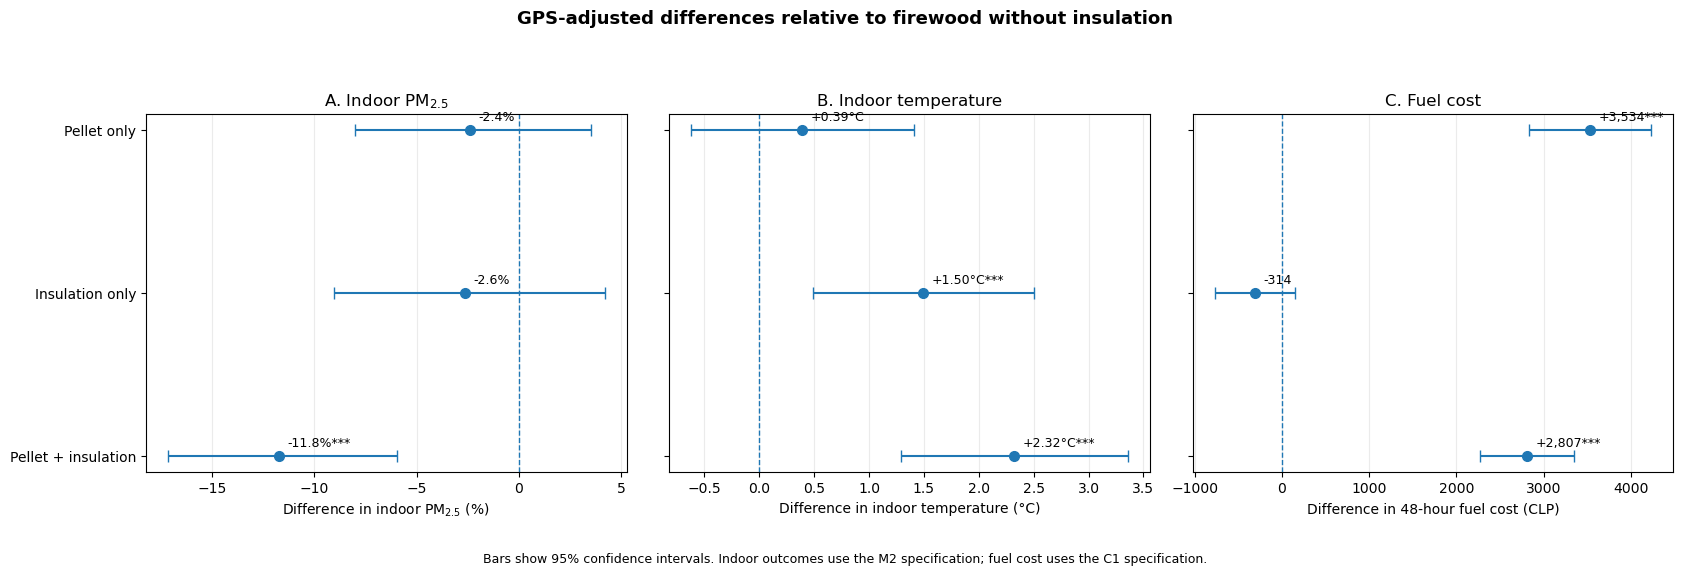

Figure saved to: C:\Users\uribep_a\OneDrive - Paul Scherrer Institut\Paper2\Output_v3\Temuco_Main_Results_v3.png


In [20]:
# ============================================================
# 19. THREE-PANEL FIGURE OF THE PRIMARY RESULTS
# ============================================================
# Panel A reports exact percentage changes in indoor PM2.5.
# Panel B translates the log-Kelvin temperature estimates into approximate °C.
# Panel C reports 48-hour fuel-cost differences in CLP.

PRIMARY_INDOOR_MODEL = "M2 GPS-weighted + municipality FE"
PRIMARY_COST_MODEL = "C1 Cost-GPS weighted WLS"

group_order = ["Pellet only", "Insulation only", "Pellet + Insulation"]
group_labels = ["Pellet only", "Insulation only", "Pellet + insulation"]

pm_plot = main_results[
    (main_results["Model"] == PRIMARY_INDOOR_MODEL)
    & (main_results["Outcome"] == "Indoor PM2.5")
].copy()
pm_plot["Effect"] = pd.Categorical(pm_plot["Effect"], categories=group_order, ordered=True)
pm_plot = pm_plot.sort_values("Effect").set_index("Effect").loc[group_order].reset_index()

temp_plot = temperature_celsius_main.copy()
temp_plot["Effect"] = pd.Categorical(temp_plot["Effect"], categories=group_order, ordered=True)
temp_plot = temp_plot.sort_values("Effect").set_index("Effect").loc[group_order].reset_index()

cost_plot = primary_cost_results.copy()
cost_plot["Effect"] = pd.Categorical(cost_plot["Effect"], categories=group_order, ordered=True)
cost_plot = cost_plot.sort_values("Effect").set_index("Effect").loc[group_order].reset_index()

y = np.arange(len(group_order))
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(17, 5.7), sharey=True)

# Panel A: indoor PM2.5.
pm_est = pm_plot["Percent change"].to_numpy()
pm_lo = pm_plot["Percent CI low"].to_numpy()
pm_hi = pm_plot["Percent CI high"].to_numpy()
axes[0].errorbar(pm_est, y, xerr=[pm_est - pm_lo, pm_hi - pm_est], fmt="o", capsize=4, linewidth=1.5, markersize=7)
axes[0].axvline(0, linestyle="--", linewidth=1)
axes[0].set_yticks(y)
axes[0].set_yticklabels(group_labels)
axes[0].invert_yaxis()
axes[0].set_xlabel("Difference in indoor PM$_{2.5}$ (%)")
axes[0].set_title("A. Indoor PM$_{2.5}$")
axes[0].grid(axis="x", alpha=0.25)
for row_index, row in pm_plot.iterrows():
    axes[0].annotate(
        f'{row["Percent change"]:.1f}%{row["Significance"]}',
        (row["Percent change"], row_index),
        xytext=(6, 7), textcoords="offset points", fontsize=9
    )

# Panel B: indoor temperature.
temp_est = temp_plot["Approx. Δ°C"].to_numpy()
temp_lo = temp_plot["Approx. Δ°C CI low"].to_numpy()
temp_hi = temp_plot["Approx. Δ°C CI high"].to_numpy()
axes[1].errorbar(temp_est, y, xerr=[temp_est - temp_lo, temp_hi - temp_est], fmt="o", capsize=4, linewidth=1.5, markersize=7)
axes[1].axvline(0, linestyle="--", linewidth=1)
axes[1].set_yticks(y)
axes[1].set_yticklabels(group_labels)
axes[1].invert_yaxis()
axes[1].set_xlabel("Difference in indoor temperature (°C)")
axes[1].set_title("B. Indoor temperature")
axes[1].grid(axis="x", alpha=0.25)
for row_index, row in temp_plot.iterrows():
    axes[1].annotate(
        f'{row["Approx. Δ°C"]:+.2f}°C{row["Significance"]}',
        (row["Approx. Δ°C"], row_index),
        xytext=(6, 7), textcoords="offset points", fontsize=9
    )

# Panel C: 48-hour fuel costs.
cost_est = cost_plot["Difference 48h (CLP)"].to_numpy()
cost_lo = cost_plot["CI low 48h (CLP)"].to_numpy()
cost_hi = cost_plot["CI high 48h (CLP)"].to_numpy()
axes[2].errorbar(cost_est, y, xerr=[cost_est - cost_lo, cost_hi - cost_est], fmt="o", capsize=4, linewidth=1.5, markersize=7)
axes[2].axvline(0, linestyle="--", linewidth=1)
axes[2].set_yticks(y)
axes[2].set_yticklabels(group_labels)
axes[2].invert_yaxis()
axes[2].set_xlabel("Difference in 48-hour fuel cost (CLP)")
axes[2].set_title("C. Fuel cost")
axes[2].grid(axis="x", alpha=0.25)
for row_index, row in cost_plot.iterrows():
    axes[2].annotate(
        f'{row["Difference 48h (CLP)"]:+,.0f}{row["Significance"]}',
        (row["Difference 48h (CLP)"], row_index),
        xytext=(6, 7), textcoords="offset points", fontsize=9
    )

fig.suptitle(
    "GPS-adjusted differences relative to firewood without insulation",
    fontsize=13,
    fontweight="bold"
)
fig.text(
    0.5,
    0.01,
    "Bars show 95% confidence intervals. Indoor outcomes use the M2 specification; "
    "fuel cost uses the C1 specification.",
    ha="center",
    fontsize=9
)
plt.tight_layout(rect=[0, 0.06, 1, 0.92])
fig.savefig(OUTPUT_PLOT, dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure saved to: {OUTPUT_PLOT.resolve()}")


> **Responds to — Editor (i) & Reviewer #1, C6a.** Derives the four within-city neighborhoods (`ZoneABDC`) from household coordinates in the `ID_LonLat` sheet, auto-selects the join key that reproduces the municipality labels, and verifies the zones nest inside municipalities. Municipality- vs neighborhood-FE are compared side by side.

# Part 5 · Spatial identification (reviewer response)

The headline additions for this revision — neighborhood fixed effects, the granularity ladder (2→20 spatial units) and Conley spatial-HAC standard errors. *Addresses Editor (i)–(ii) and Reviewer #1, C6a.*

In [21]:
# ============================================================
# SPATIAL ROBUSTNESS: NEIGHBORHOOD (ZONE) FIXED EFFECTS
# ============================================================
# Reviewer #1: "higher-level spatial fixed effects to control for differences
# between neighborhoods, so only comparing households within neighborhood."
# ZoneABDC refines the two-way municipality split (Temuco vs Padre Las Casas)
# into four within-city neighborhoods:
#   A = North-West Temuco, B = West Temuco, C = North-East Temuco,
#   D = Padre Las Casas.
#
# The zone is DERIVED HERE from household coordinates (sheet 'ID_LonLat') and
# joined on the identifier that reproduces the municipality labels. This makes
# the mapping self-validating: a manual paste previously misaligned the column
# (zones did not nest inside Comuna). Because ZoneABDC nests inside Comuna,
# C(ZoneABDC) subsumes C(Comuna) -> zone FE REPLACES municipality FE as a
# strict spatial refinement.

ZONE_FE = "ZoneABDC"
COORD_SHEET = "ID_LonLat"
LON_SPLIT, LAT_SPLIT = -72.61, -38.735   # same cuts used in the map analysis

# ---- 1. Derive the zone from coordinates ------------------------------------
coords = pd.read_excel(FILE_PATH, sheet_name=COORD_SHEET)
coords["_comuna_norm"] = coords["Comuna"].astype(str).str.strip().str.upper()

def _zone_from_xy(row):
    is_plc = (row.get("PLC", 0) == 1) or row["_comuna_norm"].startswith("PADRE")
    if is_plc:                   return "D"   # Padre Las Casas
    if row["Lon"] >= LON_SPLIT:  return "C"   # North-East Temuco
    if row["Lat"] >= LAT_SPLIT:  return "A"   # North-West Temuco
    return "B"                                # West Temuco

coords[ZONE_FE] = coords.apply(_zone_from_xy, axis=1)

# ---- 2. Pick the join key (ID vs ID2) that reproduces the municipality labels ----
truth = (
    df_cost[["ID", MUNICIPALITY_FE]]
    .drop_duplicates("ID")
    .assign(_muni=lambda d: d[MUNICIPALITY_FE].astype(str).str.strip().str.upper())
)

def _score_key(key):
    if key not in coords.columns:
        return -1.0, None
    cmap = (
        coords[[key, "_comuna_norm", ZONE_FE]]
        .dropna(subset=[key])
        .drop_duplicates(key)
        .rename(columns={key: "ID"})
    )
    merged = truth.merge(cmap, on="ID", how="left")
    agreement = (merged["_muni"] == merged["_comuna_norm"]).mean()
    return agreement, cmap[["ID", ZONE_FE]]

candidates = {k: _score_key(k) for k in ["ID", "ID2"]}
for k, (score, _) in candidates.items():
    print(f"Join on '{k}': municipality labels agree for {score:.1%} of households")

JOIN_KEY = max(candidates, key=lambda k: candidates[k][0])
best_score, zone_map = candidates[JOIN_KEY]
if best_score < 0.99:
    raise ValueError(
        f"No coordinate identifier reproduces the municipality labels cleanly "
        f"(best = '{JOIN_KEY}' at {best_score:.1%}). Check the '{COORD_SHEET}' sheet."
    )
print(f"--> attaching zones via '{JOIN_KEY}' ({best_score:.1%} municipality match)\n")

# ---- 3. Attach to the estimation frames (drop any stale copy first) ----------
def _attach_zone(frame, one_to_one=False):
    frame = frame.drop(columns=[ZONE_FE], errors="ignore")
    return frame.merge(
        zone_map, on="ID", how="left",
        validate="one_to_one" if one_to_one else "many_to_one",
    )

panel_zone = _attach_zone(df_panel_w, one_to_one=False)
cost_zone = _attach_zone(df_cost, one_to_one=True)

# ---- 4. Validate the design: nesting + treatment mix inside each zone --------
print("Zone -> Municipality nesting check "
      "(A/B/C must be TEMUCO only; D must be PADRE LAS CASAS only):")
display(pd.crosstab(cost_zone[ZONE_FE], cost_zone[MUNICIPALITY_FE]))

_nest = pd.crosstab(cost_zone[ZONE_FE], cost_zone[MUNICIPALITY_FE])
if ((_nest > 0).sum(axis=1) > 1).any():
    print("WARNING: a zone spans more than one municipality -> mapping is still "
          "misaligned. Do not interpret the neighborhood-FE results.")
else:
    print("OK: every zone sits inside a single municipality.\n")

print("Treatment groups within each zone (zone FE needs a mix per zone):")
zone_group = pd.crosstab(cost_zone[ZONE_FE], cost_zone["Group label"])
display(zone_group)
_thin = zone_group.index[(zone_group > 0).sum(axis=1) < 2].tolist()
if _thin:
    print(f"NOTE: zones with <2 treatment groups add no within-zone identifying "
          f"variation: {_thin}")

# ---- 5. Formulas: swap C(Comuna) for C(ZONE_FE) -----------------------------
BASE_RHS_MUNI = BASE_RHS + f" + C({MUNICIPALITY_FE})"
BASE_RHS_ZONE = BASE_RHS + f" + C({ZONE_FE})"
COV_RHS_MUNI  = BASE_RHS_MUNI + " + " + " + ".join(BASE_COVS)
COV_RHS_ZONE  = BASE_RHS_ZONE + " + " + " + ".join(BASE_COVS)

INDOOR_SPECS = {
    "Municipality FE (baseline M2)":     {"rhs": BASE_RHS_MUNI, "spatial": "Municipality", "adj": "GPS only"},
    "Neighborhood FE (zones A-D)":       {"rhs": BASE_RHS_ZONE, "spatial": "Neighborhood", "adj": "GPS only"},
    "Municipality FE + covariates (M3)": {"rhs": COV_RHS_MUNI,  "spatial": "Municipality", "adj": "GPS + covariates"},
    "Neighborhood FE + covariates":      {"rhs": COV_RHS_ZONE,  "spatial": "Neighborhood", "adj": "GPS + covariates"},
}

# ---- 6. Indoor PM2.5 and temperature (household-clustered SE) ----------------
indoor_rows = []
for outcome_label, outcome_variable in outcome_map.items():
    req = [outcome_variable, "PELLET", "INSULATION", "LnPMo", "LnTo",
           "Hour", "DayExp", "ID", MUNICIPALITY_FE, ZONE_FE, "weight_gps", *BASE_COVS]
    data = panel_zone.dropna(subset=req).copy()
    for spec_name, spec in INDOOR_SPECS.items():
        model = fit_clustered_model(f"{outcome_variable} ~ {spec['rhs']}", data, "weight_gps")
        c = treatment_group_contrasts(model, log_outcome=True)
        c.insert(0, "Outcome", outcome_label)
        c.insert(1, "Spatial control", spec["spatial"])
        c.insert(2, "Adjustment", spec["adj"])
        c["N"] = int(model.nobs)
        c["Spatial levels"] = data[MUNICIPALITY_FE].nunique() if spec["spatial"] == "Municipality" else data[ZONE_FE].nunique()
        indoor_rows.append(c)

zone_robustness_indoor = pd.concat(indoor_rows, ignore_index=True)
print("\n=== Spatial robustness - indoor PM2.5 & temperature "
      "(exact % change vs firewood, no insulation) ===")
display(zone_robustness_indoor[[
    "Outcome", "Spatial control", "Adjustment", "Effect",
    "Coefficient", "Percent change", "SE", "p-value",
    "Percent CI low", "Percent CI high", "Significance", "N", "Spatial levels"
]])

# ---- 7. Fuel cost (HC1 robust SE, one row per household) ---------------------
COST_RHS_MUNI  = COST_BASE_RHS + f" + C({MUNICIPALITY_FE})"
COST_RHS_ZONE  = COST_BASE_RHS + f" + C({ZONE_FE})"
COST_COVS_MUNI = COST_RHS_MUNI + " + " + " + ".join(COST_COVS)
COST_COVS_ZONE = COST_RHS_ZONE + " + " + " + ".join(COST_COVS)

COST_SPECS = {
    "Municipality FE (baseline C2)":     {"rhs": COST_RHS_MUNI,  "spatial": "Municipality", "adj": "GPS only"},
    "Neighborhood FE (zones A-D)":       {"rhs": COST_RHS_ZONE,  "spatial": "Neighborhood", "adj": "GPS only"},
    "Municipality FE + covariates (C3)": {"rhs": COST_COVS_MUNI, "spatial": "Municipality", "adj": "GPS + covariates"},
    "Neighborhood FE + covariates":      {"rhs": COST_COVS_ZONE, "spatial": "Neighborhood", "adj": "GPS + covariates"},
}

cost_rows = []
for spec_name, spec in COST_SPECS.items():
    req = ["Cost48h_ave", "PELLET", "INSULATION", "ID",
           MUNICIPALITY_FE, ZONE_FE, "weight_cost_gps", *COST_COVS]
    data = cost_zone.dropna(subset=list(dict.fromkeys(req))).copy()
    model = fit_hc1_model(f"Cost48h_ave ~ {spec['rhs']}", data, "weight_cost_gps")
    c = treatment_group_contrasts(model, log_outcome=False)
    c.insert(0, "Spatial control", spec["spatial"])
    c.insert(1, "Adjustment", spec["adj"])
    c["N"] = int(model.nobs)
    c["Spatial levels"] = data[MUNICIPALITY_FE].nunique() if spec["spatial"] == "Municipality" else data[ZONE_FE].nunique()
    cost_rows.append(c)

zone_robustness_cost = add_cost_translations(pd.concat(cost_rows, ignore_index=True), CLP_PER_USD)
print("\n=== Spatial robustness - 48-hour fuel cost (CLP vs firewood, no insulation) ===")
display(zone_robustness_cost[[
    "Spatial control", "Adjustment", "Effect",
    "Difference 48h (CLP)", "SE", "p-value",
    "CI low 48h (CLP)", "CI high 48h (CLP)",
    "Difference 48h (USD)", "Significance", "N", "Spatial levels"
]])

Join on 'ID': municipality labels agree for 40.9% of households
Join on 'ID2': municipality labels agree for 100.0% of households
--> attaching zones via 'ID2' (100.0% municipality match)

Zone -> Municipality nesting check (A/B/C must be TEMUCO only; D must be PADRE LAS CASAS only):


Comuna,PADRE LAS CASAS,TEMUCO
ZoneABDC,,
A,0,77
B,0,80
C,0,95
D,127,0


OK: every zone sits inside a single municipality.

Treatment groups within each zone (zone FE needs a mix per zone):


Group label,Firewood – No Insulation,Insulation only,Pellet + Insulation,Pellet only
ZoneABDC,,,,
A,11,21,28,17
B,11,14,30,25
C,21,23,29,22
D,51,36,10,30



=== Spatial robustness - indoor PM2.5 & temperature (exact % change vs firewood, no insulation) ===


,Outcome,Spatial control,Adjustment,Effect,Coefficient,Percent change,SE,p-value,Percent CI low,Percent CI high,Significance,N,Spatial levels
0,Indoor PM2.5,Municipality,GPS only,Pellet only,-0.0243,-2.3973,0.0302,0.4211,-7.9997,3.5463,,18377,2
1,Indoor PM2.5,Municipality,GPS only,Insulation only,-0.0268,-2.6424,0.0347,0.4400,-9.0408,4.2060,,18377,2
2,Indoor PM2.5,Municipality,GPS only,Pellet + Insulation,-0.1250,-11.7547,0.0323,0.0001,-17.1690,-5.9864,***,18377,2
3,Indoor PM2.5,Neighborhood,GPS only,Pellet only,-0.0283,-2.7870,0.0298,0.3437,-8.3113,3.0701,,18377,4
4,Indoor PM2.5,Neighborhood,GPS only,Insulation only,-0.0283,-2.7891,0.0350,0.4185,-9.2284,4.1070,,18377,4
5,Indoor PM2.5,Neighborhood,GPS only,Pellet + Insulation,-0.1287,-12.0757,0.0322,0.0001,-17.4471,-6.3548,***,18377,4
6,Indoor PM2.5,Municipality,GPS + covariates,Pellet only,-0.0266,-2.6270,0.0297,0.3703,-8.1358,3.2122,,18377,2
7,Indoor PM2.5,Municipality,GPS + covariates,Insulation only,-0.0269,-2.6504,0.0330,0.4163,-8.7565,3.8642,,18377,2
8,Indoor PM2.5,Municipality,GPS + covariates,Pellet + Insulation,-0.1295,-12.1498,0.0319,0.0001,-17.4810,-6.4743,***,18377,2
9,Indoor PM2.5,Neighborhood,GPS + covariates,Pellet only,-0.0322,-3.1699,0.0293,0.2723,-8.5812,2.5618,,18377,4



=== Spatial robustness - 48-hour fuel cost (CLP vs firewood, no insulation) ===


,Spatial control,Adjustment,Effect,Difference 48h (CLP),SE,p-value,CI low 48h (CLP),CI high 48h (CLP),Difference 48h (USD),Significance,N,Spatial levels
0,Municipality,GPS only,Pellet only,"3,485.7095",356.0351,0.0000,"2,787.8807","4,183.5382",4.7104,***,379,2
1,Municipality,GPS only,Insulation only,-366.7810,233.8010,0.1167,-825.0310,91.4690,-0.4957,,379,2
2,Municipality,GPS only,Pellet + Insulation,"2,704.1224",278.6848,0.0000,"2,157.9002","3,250.3446",3.6542,***,379,2
3,Neighborhood,GPS only,Pellet only,"3,491.9923",358.5282,0.0000,"2,789.2770","4,194.7076",4.7189,***,379,4
4,Neighborhood,GPS only,Insulation only,-362.5689,236.6667,0.1255,-826.4356,101.2979,-0.4900,,379,4
5,Neighborhood,GPS only,Pellet + Insulation,"2,709.6427",281.7334,0.0000,"2,157.4453","3,261.8401",3.6617,***,379,4
6,Municipality,GPS + covariates,Pellet only,"3,450.2995",355.9347,0.0000,"2,752.6674","4,147.9316",4.6626,***,379,2
7,Municipality,GPS + covariates,Insulation only,-400.4103,232.8328,0.0855,-856.7625,55.9420,-0.5411,*,379,2
8,Municipality,GPS + covariates,Pellet + Insulation,"2,672.3968",278.0009,0.0000,"2,127.5151","3,217.2786",3.6113,***,379,2
9,Neighborhood,GPS + covariates,Pellet only,"3,460.3683",359.1712,0.0000,"2,756.3927","4,164.3439",4.6762,***,379,4


## Reviewer response: within-neighborhood identification

Reviewer #1 asked us to (i) replace the waking-hours design with a simpler specification — treatment **main effects**, **hour** fixed effects and **neighborhood** fixed effects, with **no household** fixed effects — which should reproduce Table A5 while comparing households *within the same neighborhood*; and (ii) add a waking- vs non-waking-hours comparison as a heterogeneity check by introducing the `W` interactions on top of that main-effects model.

The two cells below implement exactly these requests, reusing the four within-city neighborhoods (`ZoneABDC`, derived from coordinates above). The **first** cell is the candidate new **Table 4** (all-hours, within-neighborhood marginal effects). The **second** decomposes each treatment effect into a *non-waking* baseline, a *waking differential* (the previous Table 4 numbers), and the *total waking* effect; hour fixed effects are dropped there because `W` is collinear with the hour of the day.

> **Responds to — Editor (i) & Reviewer #1, C6a; Reviewer #2, C5.** The **revised main specification**: treatment main effects + hour FE + **neighborhood** FE, GPS-weighted, clustered SE, **no household FE**. It reproduces Table A5 (as the reviewer anticipated) and adds the within-neighborhood comparison. **This is the candidate new Table 4.**

In [22]:
# ============================================================
# REVIEWER Eq (1'): WITHIN-NEIGHBORHOOD MAIN SPECIFICATION (all hours)
# ============================================================
# Reviewer #1: "simplify Equation (1) taking out the W dummy and its interactions
# ... household fixed effects also need to be removed ... Consider adding higher-
# level spatial fixed effects to control for differences between neighborhoods ...
# and adding hour fixed effects ... This should yield results similar to Table A5."
#
# This is the M2/M3 family (treatment MAIN effects + hour FE + day FE, GPS-
# weighted, clustered SE, NO household FE) with the two-way municipality control
# refined to the four within-city neighborhoods C(ZoneABDC). Identification comes
# from comparing households WITHIN the same neighborhood. Reported as marginal
# effects by treatment group (the Table 4 layout) for the all-hours spec.
# Requires panel_zone / ZONE_FE from the spatial-robustness cell above.

REV_BASE = "PELLET + INSULATION + PELLET:INSULATION + LnPMo + LnTo + C(Hour) + C(DayExp)"
REV_MAIN_SPECS = {
    "Municipality FE (M2)":          REV_BASE + f" + C({MUNICIPALITY_FE})",
    "Neighborhood FE (zones A-D)":   REV_BASE + f" + C({ZONE_FE})",
    "Neighborhood FE + covariates":  REV_BASE + f" + C({ZONE_FE}) + " + " + ".join(BASE_COVS),
}

rev_rows = []
for outcome_label, outcome_variable in outcome_map.items():
    req = [outcome_variable, "PELLET", "INSULATION", "LnPMo", "LnTo", "Hour", "DayExp",
           "ID", MUNICIPALITY_FE, ZONE_FE, "weight_gps", *BASE_COVS]
    data = panel_zone.dropna(subset=req).copy()
    for spec_name, rhs in REV_MAIN_SPECS.items():
        m = fit_clustered_model(f"{outcome_variable} ~ {rhs}", data, "weight_gps")
        c = treatment_group_contrasts(m, log_outcome=True)
        c.insert(0, "Outcome", outcome_label)
        c.insert(1, "Specification", spec_name)
        c["N"] = int(m.nobs)
        c["Spatial levels"] = data[ZONE_FE].nunique() if "Neighborhood" in spec_name else data[MUNICIPALITY_FE].nunique()
        rev_rows.append(c)

reviewer_main = pd.concat(rev_rows, ignore_index=True)
print("=== Reviewer Eq (1'): within-neighborhood MAIN specification, all hours ===")
print("    (marginal effect by group vs Firewood-No Insulation; % change)")
display(reviewer_main[[
    "Outcome", "Specification", "Effect", "Coefficient", "Percent change",
    "SE", "p-value", "Percent CI low", "Percent CI high", "Significance", "N", "Spatial levels"
]])

=== Reviewer Eq (1'): within-neighborhood MAIN specification, all hours ===
    (marginal effect by group vs Firewood-No Insulation; % change)


,Outcome,Specification,Effect,Coefficient,Percent change,SE,p-value,Percent CI low,Percent CI high,Significance,N,Spatial levels
0,Indoor PM2.5,Municipality FE (M2),Pellet only,-0.0243,-2.3973,0.0302,0.4211,-7.9997,3.5463,,18377,2
1,Indoor PM2.5,Municipality FE (M2),Insulation only,-0.0268,-2.6424,0.0347,0.4400,-9.0408,4.2060,,18377,2
2,Indoor PM2.5,Municipality FE (M2),Pellet + Insulation,-0.1250,-11.7547,0.0323,0.0001,-17.1690,-5.9864,***,18377,2
3,Indoor PM2.5,Neighborhood FE (zones A-D),Pellet only,-0.0283,-2.7870,0.0298,0.3437,-8.3113,3.0701,,18377,4
4,Indoor PM2.5,Neighborhood FE (zones A-D),Insulation only,-0.0283,-2.7891,0.0350,0.4185,-9.2284,4.1070,,18377,4
5,Indoor PM2.5,Neighborhood FE (zones A-D),Pellet + Insulation,-0.1287,-12.0757,0.0322,0.0001,-17.4471,-6.3548,***,18377,4
6,Indoor PM2.5,Neighborhood FE + covariates,Pellet only,-0.0322,-3.1699,0.0293,0.2723,-8.5812,2.5618,,18377,4
7,Indoor PM2.5,Neighborhood FE + covariates,Insulation only,-0.0286,-2.8147,0.0331,0.3879,-8.9136,3.6926,,18377,4
8,Indoor PM2.5,Neighborhood FE + covariates,Pellet + Insulation,-0.1341,-12.5500,0.0314,0.0000,-17.7750,-6.9930,***,18377,4
9,Indoor temperature,Municipality FE (M2),Pellet only,0.0013,0.1342,0.0018,0.4484,-0.2125,0.4821,,18377,2


> **Responds to — Editor (ii) & Reviewer #1, C6a (heterogeneity).** Adds `W` and its interactions to the revised main specification and reports each group's **waking-vs-non-waking** marginal effect — the analog of the previous Table 4, now estimated within neighborhoods.

In [23]:
# ============================================================
# WAKING-HOURS HETEROGENEITY CHECK (reviewer's second request)
# ============================================================
# Reviewer #1: "As a heterogeneity check, you can then introduce a waking time
# versus non-waking time comparison. For this, I would suggest to introduce
# additional baseline dummies for PELLET, INSULATION and PELLET:INSULATION
# interaction to current specification (1). That way, you can compare the
# difference between wake and non-wake times."
#
# We take the within-neighborhood main-effects spec and add the waking dummy W
# and its interactions. C(Hour) is dropped because W is a deterministic function
# of the hour (collinear with hour dummies) -- the same reasoning stated under
# the paper's Eq. (1). For each treatment group we report:
#     non-waking effect    = baseline main-effect linear combination
#     waking differential  = W-interaction linear combination (the old Table 4)
#     total waking effect  = non-waking + waking differential

het = panel_zone.copy()
het["W"] = ((het["Hour"] >= WAKE_START) & (het["Hour"] <= WAKE_END)).astype(int)

HET_RHS = (
    "PELLET + INSULATION + PELLET:INSULATION "               # non-waking baseline
    "+ W + W:PELLET + W:INSULATION + W:PELLET:INSULATION "   # waking differentials
    "+ LnPMo + LnTo + C(DayExp) "                            # controls + day FE
    f"+ C({ZONE_FE})"                                        # neighborhood FE (no hour FE)
)

def _term(model, factors):
    """Resolve a param name from its set of factors, robust to patsy ordering."""
    want = set(factors)
    for p in parameter_names(model):
        if set(p.split(":")) == want:
            return p
    raise KeyError(f"term {factors} not found in {parameter_names(model)}")

def waking_contrasts(model, log_outcome=True):
    P, I = "PELLET", "INSULATION"
    PI  = _term(model, [P, I])
    WP  = _term(model, ["W", P])
    WI  = _term(model, ["W", I])
    WPI = _term(model, ["W", P, I])
    blocks = [
        ("Pellet only",          [P],          [WP]),
        ("Insulation only",      [I],          [WI]),
        ("Pellet + Insulation",  [P, I, PI],   [WP, WI, WPI]),
    ]
    rows = []
    for label, base, wake in blocks:
        rows.append(linear_combination(model, base,        f"{label} · non-waking",   log_outcome))
        rows.append(linear_combination(model, wake,        f"{label} · waking diff.", log_outcome))
        rows.append(linear_combination(model, base + wake, f"{label} · total waking", log_outcome))
    return pd.DataFrame(rows)

het_rows = []
for outcome_label, outcome_variable in outcome_map.items():
    req = [outcome_variable, "PELLET", "INSULATION", "W", "LnPMo", "LnTo",
           "DayExp", "ID", ZONE_FE, "weight_gps"]
    data = het.dropna(subset=req).copy()
    m = fit_clustered_model(f"{outcome_variable} ~ {HET_RHS}", data, "weight_gps")
    c = waking_contrasts(m, log_outcome=True)
    c.insert(0, "Outcome", outcome_label)
    c["N"] = int(m.nobs)
    het_rows.append(c)

waking_heterogeneity = pd.concat(het_rows, ignore_index=True)
print("=== Waking-hours heterogeneity (neighborhood FE, main effects + W interactions) ===")
display(waking_heterogeneity[[
    "Outcome", "Effect", "Coefficient", "Percent change",
    "SE", "p-value", "Percent CI low", "Percent CI high", "Significance", "N"
]])

=== Waking-hours heterogeneity (neighborhood FE, main effects + W interactions) ===


,Outcome,Effect,Coefficient,Percent change,SE,p-value,Percent CI low,Percent CI high,Significance,N
0,Indoor PM2.5,Pellet only · non-waking,0.0180,1.8204,0.0360,0.6166,-5.1229,9.2718,,18377
1,Indoor PM2.5,Pellet only · waking diff.,-0.0679,-6.5659,0.0325,0.0368,-12.3360,-0.4161,**,18377
2,Indoor PM2.5,Pellet only · total waking,-0.0499,-4.8651,0.0322,0.1212,-10.6805,1.3290,,18377
3,Indoor PM2.5,Insulation only · non-waking,-0.0599,-5.8137,0.0418,0.1521,-13.2262,2.2321,,18377
4,Indoor PM2.5,Insulation only · waking diff.,0.0507,5.2050,0.0357,0.1557,-1.9133,12.8399,,18377
5,Indoor PM2.5,Insulation only · total waking,-0.0092,-0.9113,0.0375,0.8072,-7.9362,6.6497,,18377
6,Indoor PM2.5,Pellet + Insulation · non-waking,-0.0563,-5.4774,0.0371,0.1287,-12.1036,1.6484,,18377
7,Indoor PM2.5,Pellet + Insulation · waking diff.,-0.1069,-10.1362,0.0311,0.0006,-15.4561,-4.4815,***,18377
8,Indoor PM2.5,Pellet + Insulation · total waking,-0.1632,-15.0584,0.0343,0.0000,-20.5778,-9.1554,***,18377
9,Indoor temperature,Pellet only · non-waking,0.0018,0.1767,0.0018,0.3339,-0.1814,0.5360,,18377


> **Figura resumen (para el revisor).** Mapa de los cuatro barrios + robustez municipio-vs-barrio para PM$_{2.5}$ y temperatura + heterogeneidad hora-activa. Sintetiza visualmente la respuesta a C6a.

Saved figure to: C:\Users\uribep_a\OneDrive - Paul Scherrer Institut\Paper2\Output_v3\Temuco_Reviewer_Figures_v3.png


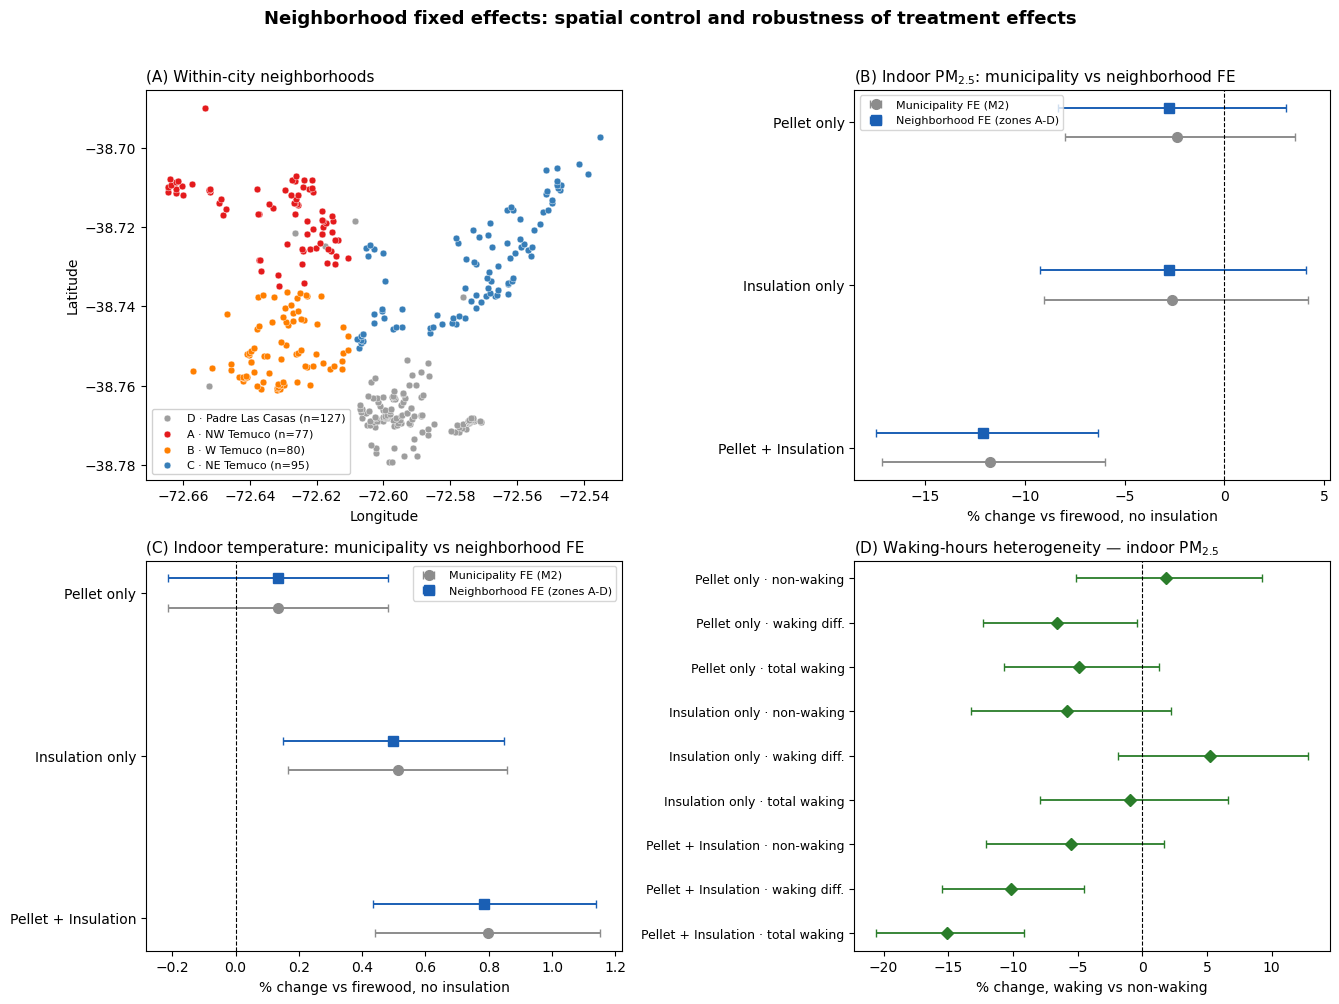

In [24]:
# ============================================================
# REVIEWER-FACING FIGURE: what the neighborhood control does
# ============================================================
# Four panels tied to the reviewer's requests:
#   (A) the four within-city neighborhoods (the spatial FE we now use);
#   (B) indoor PM2.5 effects: municipality FE vs neighborhood FE (robustness);
#   (C) indoor temperature effects: municipality FE vs neighborhood FE;
#   (D) waking- vs non-waking marginal effect by group (heterogeneity check).
# Requires: coords, reviewer_main, waking_heterogeneity (from the cells above).

import matplotlib.pyplot as plt
import numpy as np

ZONE_COLORS = {"A": "#e41a1c", "B": "#ff7f00", "C": "#377eb8", "D": "#9e9e9e"}
ZONE_NAMES  = {"A": "A · NW Temuco", "B": "B · W Temuco",
               "C": "C · NE Temuco", "D": "D · Padre Las Casas"}
SPEC_STYLE  = {"Municipality FE (M2)":        dict(color="#8c8c8c", marker="o"),
               "Neighborhood FE (zones A-D)": dict(color="#1a5fb4", marker="s")}

fig, ax = plt.subplots(2, 2, figsize=(13.5, 10.2))
fig.suptitle("Neighborhood fixed effects: spatial control and robustness of treatment effects",
             fontsize=13, fontweight="bold")

# ---- (A) neighborhood map --------------------------------------------------
m = coords[(coords["Lon"].between(-72.70, -72.50)) & (coords["Lat"].between(-38.80, -38.68))]
for z in ["D", "A", "B", "C"]:
    g = m[m[ZONE_FE] == z]
    ax[0, 0].scatter(g["Lon"], g["Lat"], s=24, c=ZONE_COLORS[z],
                     label=f"{ZONE_NAMES[z]} (n={len(coords[coords[ZONE_FE]==z])})",
                     edgecolor="white", linewidth=.3)
ax[0, 0].set_title("(A) Within-city neighborhoods", fontsize=11, loc="left")
ax[0, 0].set_xlabel("Longitude"); ax[0, 0].set_ylabel("Latitude")
ax[0, 0].legend(loc="lower left", fontsize=8, framealpha=.9)

# ---- forest-plot helper ----------------------------------------------------
def forest(axis, df_out, title):
    effects = ["Pellet only", "Insulation only", "Pellet + Insulation"]
    y = np.arange(len(effects))[::-1]
    for k, (spec, style) in enumerate(SPEC_STYLE.items()):
        off = (k - 0.5) * 0.18
        sub = df_out[df_out["Specification"] == spec].set_index("Effect")
        xs  = [sub.loc[e, "Percent change"]    for e in effects]
        lo  = [sub.loc[e, "Percent CI low"]    for e in effects]
        hi  = [sub.loc[e, "Percent CI high"]   for e in effects]
        axis.errorbar(xs, y + off,
                      xerr=[np.array(xs) - np.array(lo), np.array(hi) - np.array(xs)],
                      fmt=style["marker"], color=style["color"], capsize=3,
                      markersize=7, linewidth=1.4, label=spec)
    axis.axvline(0, color="k", lw=.8, ls="--")
    axis.set_yticks(y); axis.set_yticklabels(effects)
    axis.set_xlabel("% change vs firewood, no insulation")
    axis.set_title(title, fontsize=11, loc="left")
    axis.legend(fontsize=8, loc="best")

pm = reviewer_main[reviewer_main["Outcome"] == "Indoor PM2.5"]
tp = reviewer_main[reviewer_main["Outcome"] == "Indoor temperature"]
forest(ax[0, 1], pm, "(B) Indoor PM$_{2.5}$: municipality vs neighborhood FE")
forest(ax[1, 0], tp, "(C) Indoor temperature: municipality vs neighborhood FE")

# ---- (D) waking vs non-waking (PM2.5) --------------------------------------
wk = waking_heterogeneity[waking_heterogeneity["Outcome"] == "Indoor PM2.5"].copy()
wk["grp"] = wk["Effect"].str.replace(r"\s*\(waking vs non-waking\)", "", regex=True)
yv = np.arange(len(wk))[::-1]
ax[1, 1].errorbar(wk["Percent change"], yv,
                  xerr=[wk["Percent change"] - wk["Percent CI low"],
                        wk["Percent CI high"] - wk["Percent change"]],
                  fmt="D", color="#2a7d2a", capsize=3, markersize=6, linewidth=1.3)
ax[1, 1].axvline(0, color="k", lw=.8, ls="--")
ax[1, 1].set_yticks(yv); ax[1, 1].set_yticklabels(wk["grp"], fontsize=9)
ax[1, 1].set_xlabel("% change, waking vs non-waking")
ax[1, 1].set_title("(D) Waking-hours heterogeneity — indoor PM$_{2.5}$", fontsize=11, loc="left")

plt.tight_layout(rect=[0, 0, 1, 0.97])
try:
    _fig_path = OUT_DIR / "Temuco_Reviewer_Figures_v3.png"
    fig.savefig(_fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved figure to: {_fig_path}")
except Exception as _e:
    print("Figure not saved to disk:", _e)
plt.show()

## Robustness to spatial resolution — the granularity ladder

> **Responds to — Editor (i) & Reviewer #1, C6a** (*“higher-level spatial fixed effects to control for differences between neighborhoods”*). “Higher-level” only requires a level **above the household**, which the neighborhood FE already provide. This cell goes further: it refines the spatial partition from the municipality (2 units) up to 20 data-driven neighborhoods (K-means on household coordinates) and re-estimates the within-neighborhood main specification at each resolution. If the treatment effects stay flat across the ladder, the result does **not** depend on how finely the city is cut — the strongest form of the within-neighborhood argument. The table also reports the share of households in units that still contain ≥2 treatment combinations, i.e. where the identifying variation lives.

=== Granularity ladder: treatment effects vs number of spatial units ===


,Outcome,Resolution,Units,Effect,Percent change,Percent CI low,Percent CI high,Significance,Households in mixed units (%),N
0,Indoor PM2.5,Municipality (2),2,Pellet only,-2.3973,-7.9997,3.5463,,100.0000,18377
1,Indoor PM2.5,Municipality (2),2,Insulation only,-2.6424,-9.0408,4.2060,,100.0000,18377
2,Indoor PM2.5,Municipality (2),2,Pellet + Insulation,-11.7547,-17.1690,-5.9864,***,100.0000,18377
3,Indoor temperature,Municipality (2),2,Pellet only,0.1342,-0.2125,0.4821,,100.0000,18377
4,Indoor temperature,Municipality (2),2,Insulation only,0.5124,0.1671,0.8590,***,100.0000,18377
5,Indoor temperature,Municipality (2),2,Pellet + Insulation,0.7959,0.4414,1.1517,***,100.0000,18377
6,Indoor PM2.5,K-means 4,4,Pellet only,-2.8616,-8.3076,2.9078,,100.0000,18377
7,Indoor PM2.5,K-means 4,4,Insulation only,-3.2292,-9.5259,3.5056,,100.0000,18377
8,Indoor PM2.5,K-means 4,4,Pellet + Insulation,-12.6299,-17.8714,-7.0538,***,100.0000,18377
9,Indoor temperature,K-means 4,4,Pellet only,0.1119,-0.2306,0.4556,,100.0000,18377


Saved figure to: C:\Users\uribep_a\OneDrive - Paul Scherrer Institut\Paper2\Output_v3\Temuco_Granularity_Ladder_v3.png


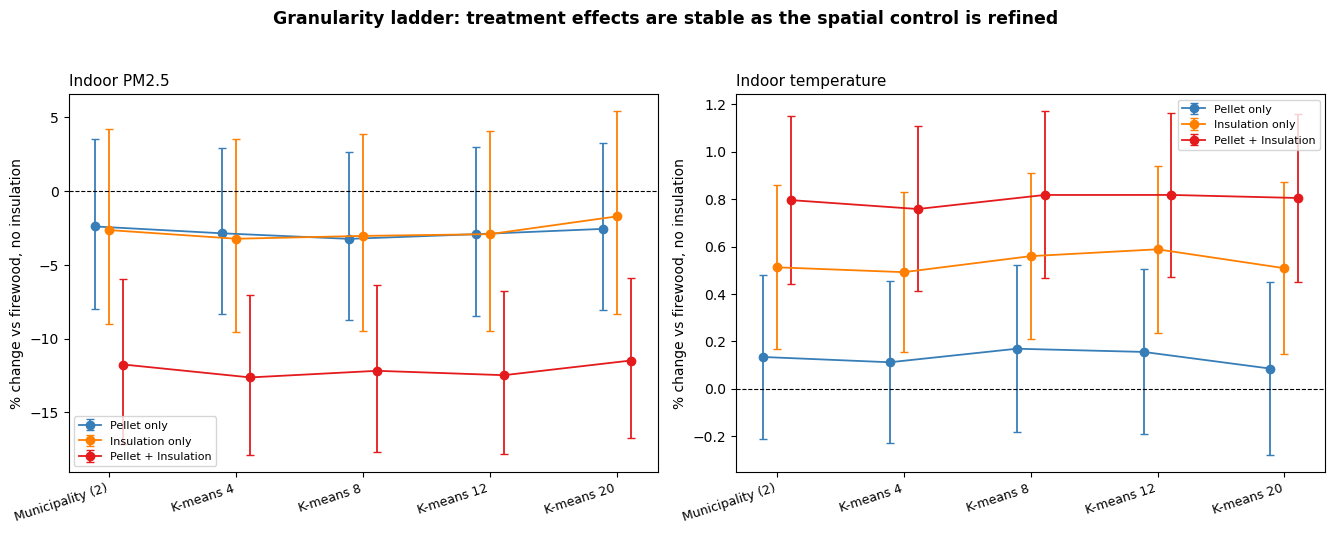

In [25]:
# ============================================================
# GRANULARITY LADDER: is the effect robust to how finely we cut space?
# ============================================================
# Reviewer #1 asked for "higher-level spatial fixed effects to control for
# differences between neighborhoods". "Higher-level" only means a level ABOVE the
# household -- a single set of neighborhood FE already satisfies it. Here we go
# further and show the estimates are stable as the spatial partition is refined
# from the municipality (2 units) up to 20 data-driven neighborhoods obtained by
# K-means on household coordinates. A flat ladder = the result does not depend on
# how finely we cut the city (the strongest possible answer to the comment).
# As the grid gets finer each unit holds fewer households and less treatment mix,
# so we also report the share of households in units that still contain >=2
# treatment combinations (the identifying variation).
# Requires: coords, JOIN_KEY, df_panel_w, helpers, outcome_map, MUNICIPALITY_FE, SEED.

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

LADDER_K = [4, 8, 12, 20]          # K-means resolutions (municipality = 2 is the anchor)
_SEED = globals().get("SEED", 42)

# ---- 1. attach household coordinates via the validated key ------------------
coord_xy = (coords[[JOIN_KEY, "Lon", "Lat"]].dropna()
            .drop_duplicates(JOIN_KEY)
            .rename(columns={JOIN_KEY: "ID", "Lon": "_lon", "Lat": "_lat"}))
panel_g = df_panel_w.drop(columns=["_lon", "_lat"], errors="ignore").merge(coord_xy, on="ID", how="left")

hh = panel_g[["ID", "_lon", "_lat"]].dropna().drop_duplicates("ID").reset_index(drop=True)
# fit the clustering on the main cloud (so a stray outlier can't waste a cluster),
# then assign every household to its nearest centroid
box = hh[hh["_lon"].between(-72.70, -72.50) & hh["_lat"].between(-38.80, -38.68)]
scaler = StandardScaler().fit(box[["_lon", "_lat"]])
for K in LADDER_K:
    km = KMeans(n_clusters=K, random_state=_SEED, n_init=10).fit(scaler.transform(box[["_lon", "_lat"]]))
    hh[f"km{K}"] = km.predict(scaler.transform(hh[["_lon", "_lat"]])).astype(str)
panel_g = panel_g.merge(hh[["ID", *[f"km{K}" for K in LADDER_K]]], on="ID", how="left")

# ladder rungs: (label, spatial column, nominal #units)
LADDER = [("Municipality (2)", MUNICIPALITY_FE, 2)] + \
         [(f"K-means {K}", f"km{K}", K) for K in LADDER_K]

# ---- 2. estimate the within-neighborhood main spec at each resolution --------
def _usable_share(data, col):
    hhd = data.drop_duplicates("ID")[[col, "PELLET", "INSULATION"]].copy()
    hhd["combo"] = hhd["PELLET"].astype(int).astype(str) + hhd["INSULATION"].astype(int).astype(str)
    mix = hhd.groupby(col)["combo"].nunique()
    keep = mix[mix >= 2].index
    return round(100 * hhd[col].isin(keep).mean(), 1)

ladder_rows = []
for label, col, _ in LADDER:
    for outcome_label, outcome_variable in outcome_map.items():
        req = [outcome_variable, "PELLET", "INSULATION", "LnPMo", "LnTo",
               "Hour", "DayExp", "ID", col, "weight_gps"]
        data = panel_g.dropna(subset=req).copy()
        rhs = (f"PELLET + INSULATION + PELLET:INSULATION + LnPMo + LnTo "
               f"+ C(Hour) + C(DayExp) + C({col})")
        m = fit_clustered_model(f"{outcome_variable} ~ {rhs}", data, "weight_gps")
        c = treatment_group_contrasts(m, log_outcome=True)
        c.insert(0, "Outcome", outcome_label)
        c.insert(1, "Resolution", label)
        c.insert(2, "Units", int(data[col].nunique()))
        c["Households in mixed units (%)"] = _usable_share(data, col)
        c["N"] = int(m.nobs)
        ladder_rows.append(c)

granularity_ladder = pd.concat(ladder_rows, ignore_index=True)
print("=== Granularity ladder: treatment effects vs number of spatial units ===")
display(granularity_ladder[[
    "Outcome", "Resolution", "Units", "Effect", "Percent change",
    "Percent CI low", "Percent CI high", "Significance",
    "Households in mixed units (%)", "N"
]])

# ---- 3. plot the ladder ------------------------------------------------------
res_order = [lbl for lbl, _, _ in LADDER]
xpos = {r: i for i, r in enumerate(res_order)}
eff_colors = {"Pellet only": "#377eb8", "Insulation only": "#ff7f00", "Pellet + Insulation": "#e41a1c"}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))
fig.suptitle("Granularity ladder: treatment effects are stable as the spatial control is refined",
             fontsize=12.5, fontweight="bold")
for axis, outcome in zip(axes, ["Indoor PM2.5", "Indoor temperature"]):
    sub = granularity_ladder[granularity_ladder["Outcome"] == outcome]
    for j, (eff, col) in enumerate(eff_colors.items()):
        s = sub[sub["Effect"] == eff].set_index("Resolution").loc[res_order]
        x = np.array([xpos[r] for r in res_order]) + (j - 1) * 0.11
        axis.errorbar(x, s["Percent change"],
                      yerr=[s["Percent change"] - s["Percent CI low"],
                            s["Percent CI high"] - s["Percent change"]],
                      fmt="o-", color=col, capsize=3, markersize=6, linewidth=1.3, label=eff)
    axis.axhline(0, color="k", lw=.8, ls="--")
    axis.set_xticks(range(len(res_order)))
    axis.set_xticklabels(res_order, rotation=18, ha="right", fontsize=9)
    axis.set_ylabel("% change vs firewood, no insulation")
    axis.set_title(outcome, fontsize=11, loc="left")
    axis.legend(fontsize=8)
plt.tight_layout(rect=[0, 0, 1, 0.95])
try:
    _p = OUT_DIR / "Temuco_Granularity_Ladder_v3.png"
    fig.savefig(_p, dpi=150, bbox_inches="tight"); print(f"Saved figure to: {_p}")
except Exception as _e:
    print("Figure not saved:", _e)
plt.show()

In [26]:
# ============================================================
# CONLEY (SPATIAL HAC) STANDARD ERRORS for the main specification
# ============================================================
# Complements the neighborhood fixed effects: the FE remove level differences
# BETWEEN neighborhoods (bias in the point estimate); Conley SEs correct the
# INFERENCE for residual spatial correlation between nearby households (bias in
# the SEs). The point estimates are unchanged -- only the SE / CI / p change.
#
# Implementation (panel-robust Conley): we collapse each household's weighted
# score to a single vector s_i (this allows ARBITRARY serial correlation within
# a household, exactly like clustering by ID), then form the "meat" as a
# spatially-weighted double sum  M = S' K S,  where K_ij = max(0, 1 - d_ij / cut)
# is a Bartlett kernel in kilometres. With cut -> 0, K = I and this reproduces
# the household-clustered SE; larger cutoffs add cross-household spatial terms.
# Requires: coords, JOIN_KEY, panel_zone, ZONE_FE, outcome_map (from the cells above).

import numpy as np, statsmodels.formula.api as smf
from scipy.stats import norm

CONLEY_CUTOFFS_KM = [1.0, 2.0]          # spatial correlation cutoffs to report
MAIN_RHS = ("PELLET + INSULATION + PELLET:INSULATION + LnPMo + LnTo "
            f"+ C(Hour) + C(DayExp) + C({ZONE_FE})")

# household coordinates via the validated key
_xy = (coords[[JOIN_KEY, "Lon", "Lat"]].dropna().drop_duplicates(JOIN_KEY)
       .rename(columns={JOIN_KEY: "ID", "Lon": "_lon", "Lat": "_lat"}))
base = panel_zone.drop(columns=["_lon", "_lat"], errors="ignore").merge(_xy, on="ID", how="left")

def _factor_idx(names, factors):
    want = set(factors)
    for j, nm in enumerate(names):
        if set(nm.split(":")) == want:
            return j
    raise KeyError(f"{factors} not in design")

def _km_distance(lon, lat):
    lat0 = np.radians(np.mean(lat))
    x = np.radians(lon) * np.cos(lat0) * 6371.0
    y = np.radians(lat) * 6371.0
    dx = x[:, None] - x[None, :]
    dy = y[:, None] - y[None, :]
    return np.sqrt(dx**2 + dy**2)

def _cov(bread, S, K):
    return bread @ (S.T @ K @ S) @ bread

rows = []
for outcome_label, yv in outcome_map.items():
    req = [yv, "PELLET", "INSULATION", "LnPMo", "LnTo", "Hour", "DayExp",
           "ID", ZONE_FE, "weight_gps", "_lon", "_lat"]
    d = base.dropna(subset=req).copy()
    res = smf.wls(f"{yv} ~ {MAIN_RHS}", data=d, weights=d["weight_gps"]).fit()

    X = np.asarray(res.model.exog)
    w = np.asarray(res.model.weights, dtype=float)
    u = np.asarray(res.resid, dtype=float)
    names = res.model.exog_names
    bread = np.linalg.inv((X * w[:, None]).T @ X)

    # household-summed scores s_i (arbitrary within-household serial correlation)
    score = (w * u)[:, None] * X
    ids = d["ID"].to_numpy()
    uniq, inv = np.unique(ids, return_inverse=True)
    S = np.zeros((len(uniq), X.shape[1]))
    np.add.at(S, inv, score)
    # one coordinate per household (aligned with uniq)
    hh_lon = d.groupby("ID")["_lon"].first().loc[uniq].to_numpy()
    hh_lat = d.groupby("ID")["_lat"].first().loc[uniq].to_numpy()
    D = _km_distance(hh_lon, hh_lat)

    # contrast vectors r for each treatment group
    iP  = _factor_idx(names, ["PELLET"])
    iI  = _factor_idx(names, ["INSULATION"])
    iPI = _factor_idx(names, ["PELLET", "INSULATION"])
    groups = {"Pellet only": [iP], "Insulation only": [iI],
              "Pellet + Insulation": [iP, iI, iPI]}

    # covariance under: clustered (K=I) and Conley at each cutoff
    cov_variants = {"Clustered by ID": _cov(bread, S, np.eye(len(uniq)))}
    for cut in CONLEY_CUTOFFS_KM:
        cov_variants[f"Conley {cut:g} km"] = _cov(bread, S, np.maximum(0.0, 1.0 - D / cut))

    beta = np.asarray(res.params)
    for gname, idx in groups.items():
        r = np.zeros(len(beta)); r[idx] = 1.0
        b = float(r @ beta)
        for se_label, V in cov_variants.items():
            var = float(r @ V @ r)
            se = np.sqrt(var) if var > 0 else np.nan
            z = b / se if se == se and se > 0 else np.nan
            p = 2 * (1 - norm.cdf(abs(z))) if z == z else np.nan
            pct = 100 * (np.exp(b) - 1)
            lo, hi = 100 * (np.exp(b - 1.96 * se) - 1), 100 * (np.exp(b + 1.96 * se) - 1)
            star = "***" if p < .01 else "**" if p < .05 else "*" if p < .10 else ""
            rows.append({"Outcome": outcome_label, "Effect": gname, "SE type": se_label,
                         "Percent change": round(pct, 3), "SE(log)": round(se, 5),
                         "p-value": round(p, 4), "% CI low": round(lo, 3),
                         "% CI high": round(hi, 3), "Significance": star})

conley_results = pd.DataFrame(rows)
print("=== Main spec (neighborhood FE): clustered vs Conley spatial-HAC SEs ===")
print("    point estimates identical; only SE / CI / significance change")
display(conley_results)

=== Main spec (neighborhood FE): clustered vs Conley spatial-HAC SEs ===
    point estimates identical; only SE / CI / significance change


,Outcome,Effect,SE type,Percent change,SE(log),p-value,% CI low,% CI high,Significance
0,Indoor PM2.5,Pellet only,Clustered by ID,-2.7870,0.0298,0.3421,-8.2940,3.0510,
1,Indoor PM2.5,Pellet only,Conley 1 km,-2.7870,0.0265,0.2860,-7.7060,2.3940,
2,Indoor PM2.5,Pellet only,Conley 2 km,-2.7870,0.0261,0.2789,-7.6360,2.3160,
3,Indoor PM2.5,Insulation only,Clustered by ID,-2.7890,0.0349,0.4171,-9.2090,4.0850,
4,Indoor PM2.5,Insulation only,Conley 1 km,-2.7890,0.0350,0.4184,-9.2270,4.1050,
5,Indoor PM2.5,Insulation only,Conley 2 km,-2.7890,0.0342,0.4080,-9.0900,3.9490,
6,Indoor PM2.5,Pellet + Insulation,Clustered by ID,-12.0760,0.0321,0.0001,-17.4310,-6.3730,***
7,Indoor PM2.5,Pellet + Insulation,Conley 1 km,-12.0760,0.0312,0.0000,-17.2990,-6.5230,***
8,Indoor PM2.5,Pellet + Insulation,Conley 2 km,-12.0760,0.0320,0.0001,-17.4230,-6.3820,***
9,Indoor temperature,Pellet only,Clustered by ID,0.1330,0.0018,0.4513,-0.2130,0.4800,


## Consolidated results export

> Escribe todas las tablas principales (robustez espacial, especificación principal del revisor, heterogeneidad hora-activa, escalera de granularidad y errores de Conley) como hojas del mismo `.xlsx`, junto a las tablas base del paper. Un solo archivo con todo.

# Part 6 · Consolidated results workbook

Writes every table above into a single `.xlsx` (base sheets + the six reviewer-response sheets).

In [27]:
# ---- CONSOLIDATED EXPORT: all reviewer-response tables into the one workbook --
# Runs after every analysis above, so it captures the neighborhood-FE robustness,
# the reviewer main spec, the waking heterogeneity, the granularity ladder and the
# Conley spatial-HAC SEs. The main export cell (#17) already wrote the base sheets
# to OUTPUT_XLSX; here we append/replace these so everything lives in ONE file.
import os

_new_sheets = {
    "Spatial_Robustness_Indoor": "zone_robustness_indoor",
    "Spatial_Robustness_Cost":   "zone_robustness_cost",
    "Reviewer_MainSpec":         "reviewer_main",
    "Wake_Neighborhood":         "waking_heterogeneity",
    "Granularity_Ladder":        "granularity_ladder",
    "Conley_SEs":                "conley_results",
}
_exists = os.path.exists(OUTPUT_XLSX)
_mode   = "a" if _exists else "w"
_kw     = {"if_sheet_exists": "replace"} if _exists else {}

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl", mode=_mode, **_kw) as _xl:
    for _sheet, _var in _new_sheets.items():
        if _var in globals():
            globals()[_var].to_excel(_xl, sheet_name=_sheet, index=False)
            print(f"  wrote sheet '{_sheet}'  ({len(globals()[_var])} rows)")
        else:
            print(f"  (skipped '{_sheet}' — {_var} not defined)")
print(f"\nConsolidated workbook: {OUTPUT_XLSX}")

  wrote sheet 'Spatial_Robustness_Indoor'  (24 rows)
  wrote sheet 'Spatial_Robustness_Cost'  (12 rows)
  wrote sheet 'Reviewer_MainSpec'  (18 rows)
  wrote sheet 'Wake_Neighborhood'  (18 rows)
  wrote sheet 'Granularity_Ladder'  (30 rows)
  wrote sheet 'Conley_SEs'  (18 rows)

Consolidated workbook: C:\Users\uribep_a\OneDrive - Paul Scherrer Institut\Paper2\Output_v3\Temuco_Heating_Analysis_v3.xlsx
